# <center>大模型RAG文档切分进阶实战

## <center>第一阶段： 数据清洗与预处理

拿到了 Elements。你可以根据每个元素的“身份”（Type）来采取不同的清洗策略：

&emsp;&emsp;在文档切分之前，针对文本内容需要进行适当的数据清洗和预处理，这一步骤可以显著提高切分质量和后续检索效果。数据清洗和预处理就是在源头把关，确保流入RAG系统的每一滴水都是干净的，这样最终输出的答案才能清澈见底。这个环节投入1小时的工作，可能在后续每个环节都为你节省10小时的调试和优化时间，并且将噪声内容清洗掉以后，会降低后期向量存储成本，提升检索的速度和回答的答案质量。对于企业级项目来说，这是性价比最高的投入之一。

### 1.1 总体目标与原则

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 8px;
        line-height: 1.6;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
</style>

数据清洗的核心目标是：

<div class="spaced-list">

- 去除无关内容和噪声
    - HTML/XML标签：div, span, p 等
    - Markdown符号：**粗体**, [链接], #标题 等
    - 代码片段：无意义的程序代码块
- 标准化文本格式
    - 修复断行问题：PDF转换经常把一句话拆成多行
    - 统一换行符：Windows(\r\n), Unix(\n), Mac(\r)
    - 合并短行：把被错误分割的短行重新合并
    - 标准化空格：多个连续空格→单个空格
- 提高切分边界识别的准确性

</div>

### 1.2 不同类型数据的清洗步骤

#### 1.2.1 纯文本文档清洗

In [ ]:
import re

# text文本处理
def clean_text(text):
    # 去除多余空白
    text = re.sub(r'\s+', ' ', text)

    # 修复断开的单词
    text = re.sub(r'(\w+)-\s+(\w+)', r'\1\2', text)

    # 标准化引号
    text = text.replace('"', '"').replace('"', '"')
    return text.strip()

# html文本处理
def clean_html(text):
    return re.sub(r'<.*?>', '', text)  # 移除HTML标签

# markdown文本处理
def clean_markdown(text):
    text = re.sub(r'\*\*(.*?)\*\*', r'\1', text)  # 移除粗体标记但保留文字
    text = re.sub(r'\[(.*?)\]\(.*?\)', r'\1', text)  # 移除链接标记但保留文字
    return text

In [ ]:
text = "Hello World! This is a **bold** text with a [link](http://example.com)."
print(clean_markdown(text))

Hello World! This is a bold text with a link.


#### 1.2.2 表格数据清洗

&emsp;&emsp;表格数据需要特别注意结构完整性：

In [ ]:
# 安装pandas
# pip install pandas

import pandas as pd

def clean_table(df):
    if type(df) != pd.DataFrame:
        df = pd.DataFrame(df)

    # 去除完全空白的行和列
    df = df.dropna(how='all').dropna(axis=1, how='all')

    # 填充NaN值
    df = df.fillna('')

    # 删除完全重复的行 (不要使用 inplace=True，它会返回 None)
    df = df.drop_duplicates()

    # 标准化列名
    df.columns = [str(col).strip() for col in df.columns]

    return df

In [ ]:
# 创建一个包含常见数据问题的示例数据集
data = {
    '姓名': ['小明', '小红', '小刚', '小丽', '小强', '小红'],
    '年龄': [18, 19, 17, 20, 250, 19],  # 250是一个异常值
    '语文成绩': [85, 92, 78, None, 88, 92],  # 包含一个缺失值
    '数学成绩': [90, None, 85, 92, 87, None],  # 包含缺失值
    '是否及格': ['是', '是', '是', '是', '是', '是']
}

df = pd.DataFrame(data)
print("原始数据：")
print(df)
print("=" * 60)

df_deal = clean_table(df)
print("处理后数据：")
print(df_deal)

原始数据：
   姓名   年龄  语文成绩  数学成绩 是否及格
0  小明   18  85.0  90.0    是
1  小红   19  92.0   NaN    是
2  小刚   17  78.0  85.0    是
3  小丽   20   NaN  92.0    是
4  小强  250  88.0  87.0    是
5  小红   19  92.0   NaN    是
处理后数据：
   姓名   年龄  语文成绩  数学成绩 是否及格
0  小明   18  85.0  90.0    是
1  小红   19  92.0          是
2  小刚   17  78.0  85.0    是
3  小丽   20        92.0    是
4  小强  250  88.0  87.0    是


#### 1.2.3 图像文档清洗

&emsp;&emsp;图像文档（如扫描的PDF）需要OCR预处理：
- 二值化、降噪、倾斜校正
- 图像处理参考：https://blog.csdn.net/2302_80961196/article/details/153827359

In [ ]:
#安装依赖包
# pip install cv2 matplotlib
import cv2
from matplotlib import pyplot as plt

# 显示图像的函数
def show_image(img, title="Image", cmap=None):
    plt.figure(figsize=(4, 2))
    if cmap:
        plt.imshow(img, cmap=cmap)
    else:
        plt.imshow(img)
    plt.title(title)
    plt.axis('off')
    plt.show()

原始图像:


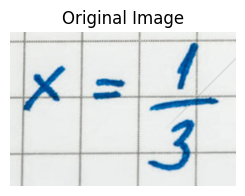

高斯模糊去噪:


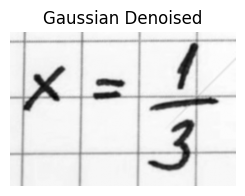

中值滤波去噪:


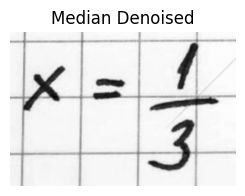

双边滤波去噪:


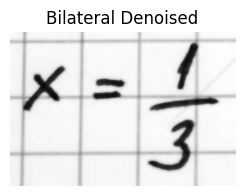

In [ ]:
def clean_image(img_path):
    """
    图像降噪 - 去除扫描文档中的噪声点
    """
    # 读取图像
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 转换为灰度图
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    print("原始图像:")
    show_image(img_rgb, "Original Image")

    # 方法1: 高斯模糊去噪
    gaussian_denoised = cv2.GaussianBlur(gray, (5, 5), 0)

    # 方法2: 中值滤波去噪 (对椒盐噪声效果好)
    median_denoised = cv2.medianBlur(gray, 3)

    # 方法3: 双边滤波 (保持边缘)
    bilateral_denoised = cv2.bilateralFilter(gray, 9, 75, 75)

    print("高斯模糊去噪:")
    show_image(gaussian_denoised, "Gaussian Denoised", cmap='gray')

    print("中值滤波去噪:")
    show_image(median_denoised, "Median Denoised", cmap='gray')

    print("双边滤波去噪:")
    show_image(bilateral_denoised, "Bilateral Denoised", cmap='gray')

    return gray, gaussian_denoised, median_denoised, bilateral_denoised

# 使用示例
gray, gaussian, median, bilateral = clean_image("手写公式.png")

#### 1.2.4 代码块清洗

&emsp;&emsp;代码块需要保持格式和缩进：
- 移除行尾空白：每行代码末尾的空格和制表符

- 合并连续空行：多个连续空行合并为一个

- 清理首尾空行：文件开头和结尾的空白行

In [ ]:
import re

def clean_code(code_text, remove_comments=False):
    """
    增强版代码清洗
    """
    if not code_text:
        return ""

    cleaned_lines = []
    in_multiline_comment = False

    for line in code_text.split('\n'):
        # 移除行尾空白
        clean_line = line.rstrip()

        # 可选：移除单行注释
        if remove_comments:
            if not in_multiline_comment:
                # 检查是否进入多行注释
                if '"""' in clean_line or "'''" in clean_line:
                    in_multiline_comment = not in_multiline_comment
                    # 简单处理：直接跳过含有多行注释符号的行
                    continue
                # 移除单行注释（# 后面的内容）
                clean_line = re.sub(r'#.*$', '', clean_line)
            else:
                # 在多行注释中，跳过这行
                if '"""' in clean_line or "'''" in clean_line:
                    in_multiline_comment = False
                continue

        # 如果行不为空，或者我们保留空行（这里保留一个空行）
        if clean_line or (cleaned_lines and not cleaned_lines[-1]):
            cleaned_lines.append(clean_line)

    # 重新组合并确保首尾没有空行
    result = '\n'.join(cleaned_lines).strip()

    # 确保以换行符结束（可选）
    if result and not result.endswith('\n'):
        result += '\n'

    return result

In [ ]:
# 测试示例
dirty_code = """
def example_function():
    # 这是一个示例函数
    data = [1, 2, 3]

    for item in data:
        print(item)



    return True

"""
print(clean_code(dirty_code))

def example_function():
    # 这是一个示例函数
    data = [1, 2, 3]
    for item in data:
        print(item)
    return True



#### 1.2.5 混合文档清洗

&emsp;&emsp;混合文档需要分类处理不同内容：
* **使用建议：**

    - 对于企业级RAG项目，你可以根据具体文档类型调整清洗策略

    - 图片处理主要是元数据清理，实际图像处理需要专门的库

    - 表格处理假设数据已经是结构化的，如果是图片表格需要先OCR识别

In [ ]:
def clean_mixed_content(content_type, content):
        """
        统一清洗入口
        content_type: 'text', 'table', 'image', 'code'
        """
        try:
            if content_type == 'text':
                text = clean_text(content)
                text = clean_html(text)
                text = clean_markdown(text)
                return text

            elif content_type == 'table':
                return clean_table(content)

            elif content_type == 'image':
                return clean_image(content)

            elif content_type == 'code':
                return clean_code(content)

            else:
                print(f"未知内容类型: {content_type}")
                return content

        except Exception as e:
            print(f"清洗 {content_type} 时出错: {e}")
            return content

def batch_clean(documents):
    """
    批量清洗文档
    documents: 列表，每个元素是 (content_type, content) 元组
    """
    results = []
    for i, (doc_type, content) in enumerate(documents):
        print(f"清洗文档 {i+1}: {doc_type}")
        cleaned = clean_mixed_content(doc_type, content)
        results.append((doc_type, cleaned))

    return results

In [ ]:
# 准备测试数据
test_documents = [
    # 文本测试数据
    ('text', '  这是一段  有很多多余  空格的文本！！！  \n\n还有换行符...  '),

    # 表格测试数据
    ('table', [
        ['  Name  ', ' Age ', ' City   '],
        [' Alice ', None, 'New York'],
        ['  Bob  ', ' 25 ', '  ']
    ]),

    # 图片测试数据（文件路径）
    #('image', '手写公式.png'),

    # 代码测试数据
    ('code', 'def hello():\n    print("world")  \n\n\n    return True  ')
]

# 执行批量清洗
print("开始清洗混合文档...")
cleaned_docs = batch_clean(test_documents)

# 显示清洗结果
print("\n=== 清洗结果 ===")
for doc_type, content in cleaned_docs:
    print(f"\n类型: {doc_type}")
    print(f"内容: ")
    print(content)
    print("-" * 50)

开始清洗混合文档...
清洗文档 1: text
清洗文档 2: table
清洗文档 3: code

=== 清洗结果 ===

类型: text
内容: 
这是一段 有很多多余 空格的文本！！！ 还有换行符...
--------------------------------------------------

类型: table
内容: 
          0      1         2
0    Name     Age    City   
1    Alice          New York
2     Bob      25           
--------------------------------------------------

类型: code
内容: 
def hello():
    print("world")
    return True

--------------------------------------------------


### 1.3 数据清洗的最佳实践

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

<div class="spaced-list">
&emsp;&emsp;数据清洗是文档切分的基础工作，良好的清洗能够显著提高后续切分质量和检索效果。

1. **保持原始结构**：清洗过程中尽量保留文档的原始结构和层次关系
2. **最小化信息损失**：只去除明确的噪声，避免删除可能有用的内容
3. **标准化格式**：统一标点符号、引号、连字符等格式元素
4. **处理特殊字符**：转义或替换可能影响后续处理的特殊字符
5. **版本控制**：保留原始文档副本，以便需要时回滚

</div>

## <center>第二阶段： RAG文档切分概述

&emsp;&emsp;RAG（Retrieval-Augmented Generation）系统中的文档切分是构建高效检索系统的关键步骤。文档切分，也称为分块（Chunking），是将长文档分割成更小、更易于管理的片段的过程，防止长文档有大部分的噪音数据进入上下文中，这些片段随后被转换为向量并存储在向量数据库中，以便在查询时进行快速检索。

<div align="center">
<img src="https://zrj18330672592.oss-cn-beijing.aliyuncs.com/20251028011335868.png" width="1000">
</div>

### 2.1 文档切分的重要性

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

文档切分直接影响RAG系统的性能表现：

<div class="spaced-list">

- **检索准确性**：合理的切分能确保检索到的片段包含完整的相关信息，避免语义割裂
- **上下文完整性**：适当的块大小保持足够的上下文信息，使LLM能够生成准确的回答
- **计算效率**：<font color='red'>合理的块大小平衡了检索精度和计算成本</font>
- **召回率与精确度**：切分策略直接影响检索系统的召回率和精确度

</div>

### 2.2 切分粒度对RAG效果的影响

&emsp;&emsp;粒度是RAG性能的"第一性变量"。不同粒度级别对系统性能有显著影响：

<div style="display: flex; justify-content: center; margin: 20px 0;">
<table style="border-collapse: collapse; width: auto; min-width: 80%;">
    <style>
        table { border: 1px solid #ddd; }
        th { background-color: #4CAF50; color: white; padding: 8px 15px; text-align: center; border: 1px solid #ddd; font-weight: bold; white-space: nowrap; }
        td { padding: 6px 12px; text-align: center; border: 1px solid #ddd; white-space: nowrap; }
        tr:nth-child(even) { background-color: #f2f2f2; }
        tr:hover { background-color: #ddd; }
    </style>
    <thead>
        <tr>
            <th>粒度级别</th>
            <th>检索准确性</th>
            <th>生成质量</th>
            <th>计算成本</th>
            <th>典型策略</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>细粒度(句子级)</td>
            <td>高</td>
            <td>低(上下文不足)</td>
            <td>高</td>
            <td>SentenceWindowNodeParser</td>
        </tr>
        <tr>
            <td>中等粒度(段落级)</td>
            <td>中高</td>
            <td>中高</td>
            <td>中</td>
            <td>SentenceSplitter</td>
        </tr>
        <tr>
            <td>粗粒度(文档级)</td>
            <td>低(噪声多)</td>
            <td>高(上下文完整)</td>
            <td>低</td>
            <td>直接使用Document</td>
        </tr>
    </tbody>
</table>
</div>

* **分块过大**： 可能导致检索到的单个块包含过多无关信息（噪音），增加了 LLM 理解上下文的难度，降低了答案的精确性，甚至可能超出 LLM 的上下文窗口限制。

* **分块过小或切分不当**： 可能破坏原文的语义连贯性，导致一个完整的知识点被拆散到多个块中。检索时可能只召回了部分信息，使得 LLM 无法获得完整的背景，难以生成全面、准确的答案。

* **未能适应文档结构**： 不同的文档类型（如论文、手册、报告、网页）具有不同的结构特点。死板的分块方式可能无法有效利用标题、列表、表格等结构信息，影响信息提取的完整性。

* <font color='red'>一般工程上，层次化切分与句子窗口相结合，通过"粗检索—细生成"的两阶段路径，有效平衡召回率与上下文完整性。</font>

### 2.3 文档切分的基本流程

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

文档切分通常包括以下基本步骤：

<div class="spaced-list">

1. **文档加载**：使用适当的文档加载器加载文档内容（unstructured，Reader等）
2. **预处理**：根据文档类型进行必要的清洗和格式化
3. **切分策略选择**：根据文档特点和需求选择合适的切分方法
4. **执行切分**：应用选定的切分策略将文档分割成块
5. **后处理**：对切分结果进行必要的调整和优化

</div>

### 2.4 切分效果评估指标

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

评估文档切分效果的常用指标包括：

<div class="spaced-list">

- **语义完整性**：切分后的块是否保持完整的语义信息，能够表达完整的含义
- **上下文连贯性**：相邻块之间的内容是否连贯，重叠部分保证思路不中断
- **检索相关性**：切分后的块是否能有效支持相关查询
- **生成质量**：基于切分块生成的回答质量
- **计算效率**：切分和检索过程的计算成本

</div>

## <center>第三阶段： LlamaIndex核心对象概念

&emsp;&emsp;LlamaIndex提供了灵活的文档处理框架，理解其核心概念是有效使用文档切分功能的基础。<font color='red'>它们是将大文档首先会读取为document对象</font>，然后拆解为适宜检索的语义片段（节点Node）。选择合适的切分器对于提升 RAG 系统的检索精度和回答质量至关重要。

### 3.1 Document和Node的概念

<div align="center">
<img src="https://zrj18330672592.oss-cn-beijing.aliyuncs.com/20251028185855232.png" width="800">
</div>

<div style="display: flex; justify-content: center; margin: 20px 0;">
<table style="border-collapse: collapse; width: auto; min-width: 80%;">
    <style>
        table { border: 1px solid #ddd; }
        th { background-color: #4CAF50; color: white; padding: 8px 15px; text-align: center; border: 1px solid #ddd; font-weight: bold; white-space: nowrap; }
        td { padding: 6px 12px; text-align: center; border: 1px solid #ddd; white-space: nowrap; }
        tr:nth-child(even) { background-color: #f2f2f2; }
        tr:hover { background-color: #ddd; }
    </style>
    <thead>
        <tr>
            <th>维度</th>
            <th>Document (文档)</th>
            <th>Node (节点)</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>概念层级</td>
            <td>顶层数据容器，代表一个完整的数据源（如一个PDF文件、一个API响应）</td>
            <td>基础数据单元，由Document解析/分块而成，代表其中一段文本</td>
        </tr>
        <tr>
            <td>核心职责</td>
            <td>数据的统一与标准化：将不同来源、格式的数据封装成统一对象，便于系统处理</td>
            <td>数据的精细化组织与关联：通过分块、元数据和关系，构建细粒度的数据网络以支持高效检索</td>
        </tr>
        <tr>
            <td>内容与关系</td>
            <td>包含原始、完整的数据内容；Document之间通常独立</td>
            <td>包含数据片段；Node之间可通过关系（如父子、先后）构建复杂的图结构</td>
        </tr>
        <tr>
            <td>典型使用场景</td>
            <td>数据加载与初始化，统一元数据管理（如为整个文档设置来源、作者）</td>
            <td>构建各类索引（向量、关键词等）的基础，实现精确的语义检索，构建复杂的关系知识图谱</td>
        </tr>
    </tbody>
</table>
</div>

#### 关于Document

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

<div class="spaced-list">

- **数据的起点**：在LlamaIndex中，任何外部数据（PDF、数据库、网页等）首先需要通过数据连接器被加载成一个或多个`Document`对象。它充当了原始数据的**统一接口**，随后，通过称为 NodeParser（节点解析器） 的组件，将Document解析为多个Node。
- **元数据承载**：`Document`级别非常适合存储文档整体的元数据，例如`file_name`（文件名）、`author`（作者）、`category`（分类）等。这些元数据可以被其下的所有`Node`继承，也可用于高级检索策略。

</div>

#### 关于Node

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

<div class="spaced-list">

- **索引的基石**：`Node`是LlamaIndex构建索引的真正原材料。将`Document`解析成`Node`的过程（常称为"分块"或"切分"）对检索性能至关重要。
- **灵活的关系定义**：Node不仅是文本块，每个`Node`可以与其他`Node`建立关系，例如`Next`（下一个）、`Previous`（上一个）、`Parent`（父级）、`Child`（子级）等。这使得LlamaIndex不仅能处理线性文本，还能构建树状或图状的复杂知识结构，这对于理解长文档的逻辑或回答需要多步推理的问题非常关键。

</div>

Document和Node在LlamaIndex中分别扮演着数据容器和语义单元的角色。理解它们的分工与协作，是有效使用LlamaIndex构建高效检索系统的关键。Document负责承载原始数据，而Node则作为构建索引、进行语义检索和生成回答的真正基石。

### 3.2 元数据传播机制

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

<font color='red'>LlamaIndex中的元数据传播遵循继承原则：</font>

<div class="spaced-list">

1. **Document级元数据**：自动传播到所有由该Document生成的Node
2. **Node级元数据**：可以覆盖或补充Document级元数据
3. **关系元数据**：存储Node之间的关系信息，如父子、前后关系

</div>

In [ ]:
from llama_index.core import Document
# 导入SentenceSplitter句子分割器
from llama_index.core.node_parser import SentenceSplitter

# 创建Document并设置元数据
doc = Document(
    text="这是一份关于RAG技术的文档...",
    metadata={
        "file_name": "rag_guide.pdf",
        "category": "技术文档",
        "author": "AI研究团队",
        "created_date": "2023-11-15"
    }
)

# 从Document创建Node时，元数据会自动传播
splitter = SentenceSplitter()
nodes = splitter.get_nodes_from_documents([doc])

# 每个node都会继承doc的metadata
nodes[0].metadata

{'file_name': 'rag_guide.pdf',
 'category': '技术文档',
 'author': 'AI研究团队',
 'created_date': '2023-11-15'}

### 3.3 Node结构



|              属性名              |                  类型                   |                  说明                  |
| :------------------------------: | :-------------------------------------: | :------------------------------------: |
|        **id_** (node_id)         |                   `str`                 | 节点的唯一标识符，可自动生成或手动指定 |
|             **text**             |                   `str`                 | 节点包含的文本内容（chunk）            |
|           **metadata**           |             `Dict[str, Any]`            | 存储文档的元数据信息（如文件名、页码等）|
|          **embedding**           |               `List[float]`             | 节点的向量嵌入表示                     |
|        **relationships**         | `Dict[NodeRelationship, RelatedNodeInfo]` | 节点间关系映射                       |
|             **hash**             |                   `str`                 | 内容的哈希值，用于去重和变更检测       |
| **excluded_embed_metadata_keys** |                `List[str]`              | embedding 时排除的元数据键             |
|  **excluded_llm_metadata_keys**  |                `List[str]`              | LLM 处理时排除的元数据键               |
|        **start_char_idx**        |              `Optional[int]`            | 在原始文档中的起始字符位置             |
|         **end_char_idx**         |              `Optional[int]`            | 在原始文档中的结束字符位置             |
|        **text_template**         |                   `str`                 | 文本格式化模板                         |
|      **metadata_template**       |                   `str`                 | 元数据格式化模板                       |

&emsp;&emsp;LlamaIndex中，切分后的基本单元是Node，每个Node包含以下核心属性：

In [ ]:
from llama_index.core.schema import TextNode

# Node的基本结构
node = TextNode(
    text="这是切分后的文本内容",           # 文本内容
    metadata={                            # 元数据
        "file_name": "document.pdf",
        "page_number": 1,
        "chunk_id": 0
    },
    id_="node_id_123",                   # 唯一标识符
    embeddings=[]                        # 文本嵌入向量(可选)
)

### 3.4 关系结构

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

切分后的Node之间可以建立多种关系：

<div class="spaced-list">

1. **前后关系**：表示Node在原文档中的顺序
2. **父子关系**：表示层次化切分中的层级关系
3. **相似关系**：表示语义相似的Node

</div>

In [ ]:
from llama_index.core.schema import NodeRelationship
import json

# Node的基本结构
node0 = TextNode(
    text="这是切分后的文本内容0",           # 文本内容
    metadata={                            # 元数据
        "file_name": "document.pdf",
        "page_number": 1,
        "chunk_id": 0
    },
    id_="node_id_0",                   # 唯一标识符
)

node1 = TextNode(
    text="这是切分后的文本内容1",           # 文本内容
    metadata={                            # 元数据
        "file_name": "document.pdf",
        "page_number": 1,
        "chunk_id": 1
    },
    id_="node_id_1",                   # 唯一标识符
)

node2 = TextNode(
    text="这是切分后的文本内容2",           # 文本内容
    metadata={                            # 元数据
        "file_name": "document.pdf",
        "page_number": 1,
        "chunk_id": 2
    },
    id_="node_id_2",                   # 唯一标识符
)

# 顺序关系
node1.relationships[NodeRelationship.SOURCE] = node0.id_
node1.relationships[NodeRelationship.NEXT] = node2.id_
node2.relationships[NodeRelationship.PREVIOUS] = node1.id_

# 层次化关系
node2.relationships[NodeRelationship.SOURCE] = node0.id_
node1.relationships[NodeRelationship.CHILD] = node2.id_
node2.relationships[NodeRelationship.PARENT] = node1.id_

# 打印节点关系
print(node1.relationships)
print(node2.relationships)


{<NodeRelationship.SOURCE: '1'>: 'node_id_0', <NodeRelationship.NEXT: '3'>: 'node_id_2', <NodeRelationship.CHILD: '5'>: 'node_id_2'}
{<NodeRelationship.PREVIOUS: '2'>: 'node_id_1', <NodeRelationship.SOURCE: '1'>: 'node_id_0', <NodeRelationship.PARENT: '4'>: 'node_id_1'}


**关系类型说明**
* **SOURCE** (值=1)
    - 含义: 指向源文档(Document)的引用
    - 作用: 建立节点与原始文档的追溯链接
    - 使用场景: 每个从 Document 分割出的 Node 都会有一个 SOURCE 关系指向原始文档
* **PREVIOUS** (值=2)
    - 含义: 指向文档中前一个兄弟节点
    - 作用: 构建文档的线性阅读顺序
    - 使用场景: 用于保持文档的原始顺序,支持上下文窗口扩展
    - 典型应用: Sentence Window Retrieval 技术
* **NEXT** (值=3)
    - 含义: 指向文档中下一个兄弟节点
    - 作用: 与 PREVIOUS 配合构成双向链表结构
    - 使用场景: 支持前后文扩展检索
* **PARENT** (值=4)
    - 含义: 指向层级结构中的父节点
    - 作用: 建立层级树状结构,支持粗粒度到细粒度的递归组织
    - 使用场景: HierarchicalNodeParser 的核心机制
    - 层级示例:
        - Level 1: chunk_size=2048 (父节点)
        - Level 2: chunk_size=512 (子节点)
        - Level 3: chunk_size=128 (孙节点)
*   **CHILD** (值=5)
    - 含义: 指向子节点集合
    - 作用: 父节点维护对所有子节点的引用
    - 特点: 值可以是 List[RelatedNodeInfo],因为一个父节点可能有多个子节点

## <center>第四阶段： 文档切分核心原则

&emsp;&emsp;有效的文档切分应遵循以下核心原则，以确保切分结果既保持语义完整性又满足检索需求。

### 4.1 语义完整性原则

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

<div class="spaced-list">

**核心思想**：切分应尽量不破坏语义单元的完整性，避免在句子或段落中间进行不合理的分割。

- **句子边界优先**：优先在自然语言句子结束处（如句号、问号、感叹号）进行分割
- **段落边界考虑**：在段落分隔符处进行分割，保持段落的完整性
- **主题连贯性**：切分点应选择在主题转换处，避免将不同主题的内容混合在一个块中

</div>

* **例如：**
    - 块1: "人工智能的核心技术包括机器学习和深度学习。"
    - 块2: "这两者都属于监督学习的范畴。"

### 4.2 长度控制原则

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

<div class="spaced-list">

**核心思想**：控制每个文本块的长度，使其适应模型的上下文限制和检索需求。
- **模型上下文限制**：确保块大小不超过模型的输入限制
    - DeepSeek-R1: 128K tokens
- **检索效率考虑**：过大的块会增加检索噪声，过小的块会丢失上下文
    - 对于一般文档：300-800 tokens
    - 技术文档：400-600 tokens
    - 对话记录：200-400 tokens

</div>

### 4.3 重叠率原则

<div align="center">
<img src="https://zrj18330672592.oss-cn-beijing.aliyuncs.com/20251028011335867.png" width="800">
</div>

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

<div class="spaced-list">

**核心思想**：在相邻文本块之间设置适当的重叠区域，避免重要信息在边界处丢失。
- **上下文连续性**：重叠区域确保跨边界的语义连续性
- **信息完整性**：防止关键信息因切分而被分割到不同块中
- **重叠大小优化**：通常设置为块大小的10-20%，根据具体应用场景调整

</div>

### 4.4 特殊格式策略原则

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

<div class="spaced-list">

**核心思想**：针对特殊格式的文档（如代码、表格、列表）采用专门的切分策略。
- **代码块完整性**：保持函数、类等代码单元的完整性
- **表格结构保持**：尽量保持表格的完整性，避免将表格内容分割
- **列表项处理**：保持列表项的完整性，避免将单个列表项分割

</div>

## <center>第五阶段： 切分工具选型与实战

&emsp;&emsp;LlamaIndex提供了多种切分工具，适应不同的文档类型和应用场景。了解这些工具的特点和适用场景是选择合适切分策略的关键。

<div style="display: flex; justify-content: center; margin: 20px 0;">
<table style="border-collapse: collapse; width: auto; min-width: 80%;">
    <style>
        table { border: 1px solid #ddd; }
        th { background-color: #4CAF50; color: white; padding: 8px 15px; text-align: center; border: 1px solid #ddd; font-weight: bold; white-space: nowrap; }
        td { padding: 6px 12px; text-align: center; border: 1px solid #ddd; white-space: nowrap; }
        tr:nth-child(even) { background-color: #f2f2f2; }
        tr:hover { background-color: #ddd; }
    </style>
    <thead>
        <tr>
            <th>维度</th>
            <th>TextSplitter</th>
            <th>NodeParser</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>核心定位</td>
            <td>基础的文本分割工具</td>
            <td>高级的文档解析与节点生成框架</td>
        </tr>
        <tr>
            <td>处理逻辑</td>
            <td>通常基于固定规则，如长度、标点或字符递归分割</td>
            <td>除基础分割外，可集成语义分割、代码解析等复杂策略</td>
        </tr>
        <tr>
            <td>输出结果</td>
            <td>文本块（字符串列表）</td>
            <td>Node对象列表，包含文本、元数据及节点间关系信息</td>
        </tr>
        <tr>
            <td>语义感知</td>
            <td>通常不具备</td>
            <td>部分解析器（如SemanticSplitterNodeParser）具备语义感知能力</td>
        </tr>
        <tr>
            <td>性能特点</td>
            <td>轻量快速，计算开销小</td>
            <td>功能更强的解析器（如语义分割）可能速度较慢，计算成本高</td>
        </tr>
        <tr>
            <td>适用场景</td>
            <td>
                <div class="list-container">
                    <div class="list-item">
                        <div class="list-content">基于语义相似度进行文本切分，保持语义连贯性</div>
                    </div>
                    <div class="list-item">
                        <div class="list-content">处理主题转换自然、结构复杂的文档</div>
                    </div>
                    <div class="list-item">
                        <div class="list-content">对切分质量要求较高的生产环境</div>
                    </div>
                </div>
            </td>
            <td>
                <div class="list-container">
                    <div class="list-item">
                        <div class="list-content">构建生产级RAG系统</div>
                    </div>
                    <div class="list-item">
                        <div class="list-content">处理复杂文档（如代码、学术论文）</div>
                    </div>
                    <div class="list-item">
                        <div class="list-content">需要利用节点间关系（如父节点、子节点）的复杂查询</div>
                    </div>
                </div>
            </td>
        </tr>
    </tbody>
</table>
</div>

### 5.1 Text-Splitters（文本分割器）类型

&emsp;&emsp;Text-Splitters专注于将<font color='red'>任意文本字符串</font>拆分成多个片段，按字符/句子/token/自定义分隔规则切分，通常只关心文本长度与重叠上下文，不会理解文件格式。

#### 5.1.1 TokenTextSplitter Token切分器

&emsp;&emsp;TokenTextSplitter按照token长度进行切分，适用于需要精确控制token数量的场景，特别是在有严格token限制的嵌入模型或语言模型中使用。

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

**核心特性**：

<div class="spaced-list">

- 基于token而非字符进行切分，更准确地反映模型处理能力
- 支持不同的token计算方法（如tiktoken、huggingface tokenizer）
- 适用于多语言场景，不同语言的token密度不同

</div>

**产生的问题：**

1. 语义“腰斩”

2. 表格“粉碎机”，如果你辛辛苦苦用 unstructured 解析出了 Markdown 表格，     TokenTextSplitter 会完全无视 | 和 - 的结构，强行按 512 Token 切分
3. 中文适配差

In [ ]:
from llama_index.core.node_parser import TokenTextSplitter

# 初始化 TokenTextSplitter
token_splitter = TokenTextSplitter(
    chunk_size=512,        # 每 chunk 目标 token 数（可调）
    chunk_overlap=64,      # 重叠 token 数（可调）
    separator=" "           # 分隔符（一般用空格）
)

# 将 documents 转成 nodes（LlamaIndex 内部 node/fragment）
#nodes_from_tokens = token_splitter.get_nodes_from_documents(documents)
#print(nodes_from_tokens[1].get_content())

# 测试文本
test_text = """在检索增强生成（RAG）系统中，文档切分与 Node 转换作为连接原始数据与语言模型的关键预处理环节，直接决定了系统的检索精度、生成质量及整体性能。行业实践数据表明，90% 的 RAG 效果问题源于元数据与分块策略不当，而通过优化分块策略可使检索准确率提升 30 - 50%，语义分块较固定分块的准确率优势可达 27%。这一技术环节的重要性体现在：分块过大易引入冗余噪音，增加语言模型理解负担；分块过小或切分不当则可能破坏语义连贯性，导致完整知识点被拆分；未能适配文档结构的机械分块方式还会忽视标题、列表等结构化信息，影响信息提取完整性。
LlamaIndex 作为连接自定义数据与大语言模型（LLMs）的核心框架，通过将文档（如 PDF、文本文件）分解为包含文本内容、向量嵌入和元数据的 Node 组件，构建了结构化文档管理的技术范式。其核心抽象在于将原始文档转换为语义连贯的 Node 集合，向量存储仅保留 Node 内容的嵌入向量与文本信息，这一机制简化了索引构建流程并提升了检索相关性。文档切分与 Node 转换的质量不仅影响向量检索的效率，更决定了上下文增强（Context Augmentation）这一 RAG 核心能力的实现效果。
本文聚焦文档切分与 Node 转换的技术实践，结合 LlamaIndex 框架的实现机制，系统调研分块策略设计、元数据管理及 Node 组件化等关键技术点。通过分析行业最佳实践与典型案例，旨在为 RAG 系统开发者提供可落地的优化方案，解决分块噪音、语义断裂、结构信息丢失等核心痛点，为构建高性能检索增强生成应用奠定技术基础。"""

# 按照文本来进行切分
nodes_from_tokens = token_splitter.split_text(test_text)
# 打印切分后的文本数量
print( "切分后的文本数量: " + str(len(nodes_from_tokens)))
print("===============================================")
# 打印第一个文本
print("第一个文本:")
print(nodes_from_tokens[0])
print("===============================================")
# 打印第二个文本
print("第二个文本:")
print(nodes_from_tokens[1])
print("===============================================")

切分后的文本数量: 2
第一个文本:
在检索增强生成（RAG）系统中，文档切分与 Node 转换作为连接原始数据与语言模型的关键预处理环节，直接决定了系统的检索精度、生成质量及整体性能。行业实践数据表明，90% 的 RAG 效果问题源于元数据与分块策略不当，而通过优化分块策略可使检索准确率提升 30 - 50%，语义分块较固定分块的准确率优势可达 27%。这一技术环节的重要性体现在：分块过大易引入冗余噪音，增加语言模型理解负担；分块过小或切分不当则可能破坏语义连贯性，导致完整知识点被拆分；未能适配文档结构的机械分块方式还会忽视标题、列表等结构化信息，影响信息提取完整性。
LlamaIndex 作为连接自定义数据与大语言模型（LLMs）的核心框架，通过将文档（如 PDF、文本文件）分解为包含文本内容、向量嵌入和元数据的 Node 组件，构建了结构化文档管理的技术范式。其核心抽象在于将原始文档转换为语义连贯的 Node 集合，向量存储仅保留 Node 内容的嵌入向量与文本信息，这一机制简化了索引构建流程并提升了检索相关性。文档切分与 Node 转换的质量不仅影响向量检索的效率，更决定了上下文增强（Context Augmentation）这一 RAG
第二个文本:
Node 转换的质量不仅影响向量检索的效率，更决定了上下文增强（Context Augmentation）这一 RAG 核心能力的实现效果。
本文聚焦文档切分与 Node 转换的技术实践，结合 LlamaIndex 框架的实现机制，系统调研分块策略设计、元数据管理及 Node 组件化等关键技术点。通过分析行业最佳实践与典型案例，旨在为 RAG 系统开发者提供可落地的优化方案，解决分块噪音、语义断裂、结构信息丢失等核心痛点，为构建高性能检索增强生成应用奠定技术基础。


#### 5.1.2 SentenceSplitter 句子切分器

&emsp;&emsp;SentenceSplitter是一种基于自然语言句子和段落边界进行分割的解析器，类似于LangChain的RecursiveCharacterTextSplitter。它优先在句子结束处或段落分隔符处进行分割，尽量避免在句子中间切断，以保持语义单元的完整性。

<div align="center">
<img src="https://zrj18330672592.oss-cn-beijing.aliyuncs.com/20251028011335869.png" width="800">
</div>

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

**核心特性与工作原理**：

<div class="spaced-list">

- **保持句子完整性**：首先尝试按句子边界（如中文的"。""！""？"或英文的".""""!"）进行分割
- **递归分割策略**：如果单个句子长度超过chunk_size，递归地使用更小的分隔符进行分割
- **重叠控制**：通过chunk_overlap参数，允许相邻文本块之间有少量重叠的token
- **多语言支持**：通过separator参数可以自定义分隔符

</div>

&emsp;&emsp;**关键参数**：

<div style="display: flex; justify-content: center; margin: 20px 0;">
<table style="border-collapse: collapse; width: auto; min-width: 80%;">
    <style>
        table { border: 1px solid #ddd; }
        th { background-color: #4CAF50; color: white; padding: 8px 15px; text-align: center; border: 1px solid #ddd; font-weight: bold; white-space: nowrap; }
        td { padding: 6px 12px; text-align: center; border: 1px solid #ddd; white-space: nowrap; }
        tr:nth-child(even) { background-color: #f2f2f2; }
        tr:hover { background-color: #ddd; }
    </style>
    <thead>
        <tr>
            <th>参数名</th>
            <th>类型</th>
            <th>说明</th>
            <th>默认值</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>chunk_size</td>
            <td>int</td>
            <td>每个文本块的目标最大token数</td>
            <td>1024</td>
        </tr>
        <tr>
            <td>chunk_overlap</td>
            <td>int</td>
            <td>相邻文本块之间重叠的token数</td>
            <td>200</td>
        </tr>
        <tr>
            <td>separator</td>
            <td>str</td>
            <td>用于分割的主要分隔符</td>
            <td>" " (空格)</td>
        </tr>
        <tr>
            <td>paragraph_separator</td>
            <td>str</td>
            <td>用于识别段落的分隔符</td>
            <td>"\n\n\n"</td>
        </tr>
    </tbody>
</table>
</div>

&emsp;&emsp;**适用场景**：
SentenceSplitter非常适用于自然语言文本，<font color='red'>也叫做纯文本切分器</font>,如新闻文章、博客文章、书籍章节等结构清晰的散文体内容。它是LlamaIndex中最常用且默认的文本分割器之一。

In [ ]:
from llama_index.core.node_parser import SentenceSplitter
# 初始化 SentenceSplitter
sentence_splitter = SentenceSplitter(
    chunk_size=512,      # 这里 chunk_size 表示 token 近似或字符近似，视版本调整
    chunk_overlap=64
)
# 将 documents 转成 nodes
# nodes_from_sentences = sentence_splitter.get_nodes_from_documents(documents)
# print(nodes_from_sentences[0].get_content())

# 测试文本
test_text = """在检索增强生成（RAG）系统中，文档切分与 Node 转换作为连接原始数据与语言模型的关键预处理环节，直接决定了系统的检索精度、生成质量及整体性能。行业实践数据表明，90% 的 RAG 效果问题源于元数据与分块策略不当，而通过优化分块策略可使检索准确率提升 30 - 50%，语义分块较固定分块的准确率优势可达 27%。这一技术环节的重要性体现在：分块过大易引入冗余噪音，增加语言模型理解负担；分块过小或切分不当则可能破坏语义连贯性，导致完整知识点被拆分；未能适配文档结构的机械分块方式还会忽视标题、列表等结构化信息，影响信息提取完整性。
LlamaIndex 作为连接自定义数据与大语言模型（LLMs）的核心框架，通过将文档（如 PDF、文本文件）分解为包含文本内容、向量嵌入和元数据的 Node 组件，构建了结构化文档管理的技术范式。其核心抽象在于将原始文档转换为语义连贯的 Node 集合，向量存储仅保留 Node 内容的嵌入向量与文本信息，这一机制简化了索引构建流程并提升了检索相关性。文档切分与 Node 转换的质量不仅影响向量检索的效率，更决定了上下文增强（Context Augmentation）这一 RAG 核心能力的实现效果。
本文聚焦文档切分与 Node 转换的技术实践，结合 LlamaIndex 框架的实现机制，系统调研分块策略设计、元数据管理及 Node 组件化等关键技术点。通过分析行业最佳实践与典型案例，旨在为 RAG 系统开发者提供可落地的优化方案，解决分块噪音、语义断裂、结构信息丢失等核心痛点，为构建高性能检索增强生成应用奠定技术基础。"""


# 按照文本来进行切分
nodes_from_sentences = sentence_splitter.split_text(test_text)
print( "切分后的文本数量: " + str(len(nodes_from_sentences)))
print("===============================================")
print("第一个文本:")
print(nodes_from_sentences[0])
print("===============================================")
print("第二个文本:")
print(nodes_from_sentences[1])
print("===============================================")

切分后的文本数量: 2
第一个文本:
在检索增强生成（RAG）系统中，文档切分与 Node 转换作为连接原始数据与语言模型的关键预处理环节，直接决定了系统的检索精度、生成质量及整体性能。行业实践数据表明，90% 的 RAG 效果问题源于元数据与分块策略不当，而通过优化分块策略可使检索准确率提升 30 - 50%，语义分块较固定分块的准确率优势可达 27%。这一技术环节的重要性体现在：分块过大易引入冗余噪音，增加语言模型理解负担；分块过小或切分不当则可能破坏语义连贯性，导致完整知识点被拆分；未能适配文档结构的机械分块方式还会忽视标题、列表等结构化信息，影响信息提取完整性。
LlamaIndex 作为连接自定义数据与大语言模型（LLMs）的核心框架，通过将文档（如 PDF、文本文件）分解为包含文本内容、向量嵌入和元数据的 Node 组件，构建了结构化文档管理的技术范式。其核心抽象在于将原始文档转换为语义连贯的 Node 集合，向量存储仅保留 Node 内容的嵌入向量与文本信息，这一机制简化了索引构建流程并提升了检索相关性。文档切分与 Node 转换的质量不仅影响向量检索的效率，更决定了上下文增强（Context Augmentation）这一 RAG 核心能力的实现效果。
第二个文本:
文档切分与 Node 转换的质量不仅影响向量检索的效率，更决定了上下文增强（Context Augmentation）这一 RAG 核心能力的实现效果。
本文聚焦文档切分与 Node 转换的技术实践，结合 LlamaIndex 框架的实现机制，系统调研分块策略设计、元数据管理及 Node 组件化等关键技术点。通过分析行业最佳实践与典型案例，旨在为 RAG 系统开发者提供可落地的优化方案，解决分块噪音、语义断裂、结构信息丢失等核心痛点，为构建高性能检索增强生成应用奠定技术基础。


**递归测试**
   * 如果分块的大小超过预定义的块大小限制，则将每个块拆分成更小的块。然而，如果块符合块大小限制，则不再进行进一步拆分
   * 与固定大小的块不同，这种方法还保持了语言的自然流畅性，并保留了完整的思想


<div align="center">
<img src="https://zrj18330672592.oss-cn-beijing.aliyuncs.com/20251028011335872.gif" width="700">
</div>

In [ ]:
from llama_index.core.node_parser import SentenceSplitter
from llama_index.core.schema import Document

# SentenceSplitter 测试递归切分
# 示例文本：一个长句子和一个短句子
text = "这是一个非常长的句子，它包含了多个逗号分隔的部分，和一些短的文本，因此整个句子的长度会很容易超过我们设定的块大小限制。短期。"
document = Document(text=text)

# 初始化SentenceSplitter，设定块大小非常小以触发递归分割
splitter = SentenceSplitter(chunk_size=10, chunk_overlap=0,separator="，。！？!?.\n¡¿")
nodes = splitter.get_nodes_from_documents([document])

# 打印分割结果
print("=" * 60)
for i, node in enumerate(nodes):
    print(f"块 {i+1}: {node.text}")

print("=" * 60)
print("打印Node信息：")
print(nodes[0].__dict__)


Metadata length (0) is close to chunk size (10). Resulting chunks are less than 50 tokens. Consider increasing the chunk size or decreasing the size of your metadata to avoid this.
块 1: 这是一个非常长的句
块 2: 子，它包含了多个
块 3: 逗号分隔的部分，
块 4: 和一些短的文本，
块 5: 因此整个句子的长度
块 6: 会很容易超过我们设
块 7: 定的块大小限制。
块 8: 短期。
打印Node信息：
{'id_': '676df5e7-c347-4b6c-a101-ccf39afa5da1', 'embedding': None, 'metadata': {}, 'excluded_embed_metadata_keys': [], 'excluded_llm_metadata_keys': [], 'relationships': {<NodeRelationship.SOURCE: '1'>: RelatedNodeInfo(node_id='ee8872cd-4cd2-48b4-ba36-45a735e1cb84', node_type=<ObjectType.DOCUMENT: '4'>, metadata={}, hash='5941844fa9c40295c3fe1ee08abb5952ab4590d1951fb2150f644e3f19a18159'), <NodeRelationship.NEXT: '3'>: RelatedNodeInfo(node_id='8a7311c7-477c-4bcc-8929-2c155d9d6c07', node_type=<ObjectType.TEXT: '1'>, metadata={}, hash='e611f789a713d9540163feb55ff3c55fb0f80f43142631e1ce9c642ec49944ff')}, 'metadata_template': '{key}: {value}', 'metadata_separator': '\n', 'text': '这是一个非常长的句', 'mi

```python
# TextNode节点信息
{
	'id_': '5c0c3c5f-614e-41fb-b26b-eec080d8096e',
	'embedding': None,
	'metadata': {},
	'excluded_embed_metadata_keys': [],
	'excluded_llm_metadata_keys': [],
	'relationships': { < NodeRelationship.SOURCE: '1' > :RelatedNodeInfo(node_id = 'c21e5d07-d7d6-43ed-a54c-523ec7046359', node_type = <ObjectType.DOCUMENT: '4' > , metadata = {},
		hash = '5941844fa9c40295c3fe1ee08abb5952ab4590d1951fb2150f644e3f19a18159'),
		<NodeRelationship.NEXT: '3' > :RelatedNodeInfo(node_id = '7d757fbc-4f2a-48aa-852a-8be7692b0572', node_type = <ObjectType.TEXT: '1' > , metadata = {},
		hash = 'e611f789a713d9540163feb55ff3c55fb0f80f43142631e1ce9c642ec49944ff')
	},
	'metadata_template': '{key}: {value}',
	'metadata_separator': '\n',
	'text': '这是一个非常长的句',
	'mimetype': 'text/plain',
	'start_char_idx': 0,
	'end_char_idx': 9,
	'metadata_seperator': '\n',
	'text_template': '{metadata_str}\n\n{content}'
}
```


#### 5.1.3 CodeSplitter 代码切分器

&emsp;&emsp;CodeSplitter专为编程语言源代码设计，利用编程语言的抽象语法树（AST）来理解代码结构，确保将代码按功能单元进行分割。

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 8px;
        line-height: 1.6;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
</style>

**核心特性**：

<div class="spaced-list">

- 基于抽象语法树（AST）的结构化解析
- 语言特定，需要指定编程语言
- 保持代码块的功能完整性

</div>

In [ ]:
#安装依赖
#!pip install tree_sitter tree_sitter_language_pack

In [ ]:
from llama_index.core.node_parser import CodeSplitter
from llama_index.core.schema import Document

# 示例Python代码：一个简单的函数和类
sample_code = '''
def calculate_fibonacci(n):
    """计算斐波那契数列的第n项"""
    if n <= 1:
        return n
    else:
        return calculate_fibonacci(n-1) + calculate_fibonacci(n-2)

class MathOperations:
    """一个简单的数学操作类"""

    def __init__(self):
        self.version = "1.0"

    def factorial(self, n):
        """计算阶乘"""
        if n == 0:
            return 1
        result = 1
        for i in range(1, n+1):
            result *= i
        return result

    def is_prime(self, n):
        """判断是否为质数"""
        if n < 2:
            return False
        for i in range(2, int(n**0.5)+1):
            if n % i == 0:
                return False
        return True
'''

# 创建文档对象
# document = Document(text=sample_code)
#
# 初始化CodeSplitter，指定Python语言
code_splitter = CodeSplitter(
    language="python",    # 指定编程语言
    chunk_lines=10,       # 每块大约行数
    chunk_lines_overlap=2, # 块之间重叠行数
    max_chars=600        # 每块最大字符数
)

# 执行切分
# nodes = code_splitter.get_nodes_from_documents([document])
nodes = code_splitter.split_text(sample_code)

print(f"原始代码字符数: {len(sample_code)}")
print(f"切分后的节点数量: {len(nodes)}")
print("\n" + "="*50 + "\n")

# 显示切分结果
for i, node in enumerate(nodes):
    print(f"节点 {i+1} (字符数: {len(node)}):")
    print("-" * 30)
    print(node)
    print("\n" + "="*50 + "\n")

原始代码字符数: 655
切分后的节点数量: 2


节点 1 (字符数: 159):
------------------------------
def calculate_fibonacci(n):
    """计算斐波那契数列的第n项"""
    if n <= 1:
        return n
    else:
        return calculate_fibonacci(n-1) + calculate_fibonacci(n-2)


节点 2 (字符数: 492):
------------------------------
class MathOperations:
    """一个简单的数学操作类"""

    def __init__(self):
        self.version = "1.0"

    def factorial(self, n):
        """计算阶乘"""
        if n == 0:
            return 1
        result = 1
        for i in range(1, n+1):
            result *= i
        return result

    def is_prime(self, n):
        """判断是否为质数"""
        if n < 2:
            return False
        for i in range(2, int(n**0.5)+1):
            if n % i == 0:
                return False
        return True




### 5.2 File-Based Node Parsers（文件型节点切分器）

&emsp;&emsp;File-Based Node Parsers面向文件类型与结构（如Markdown、JSON、PDF、HTML、代码文件等），会根据文件的语义/格式选择专门解析器，把整个文件解析成带元数据的Node，可能保持章节/层级、标题、表格等结构。

#### 5.2.1 MarkdownNodeParser markdown切分器

切分器&emsp;&emsp;MarkdownNodeParser专门用于处理Markdown文件，能够识别Markdown的层级结构（如标题、列表、代码块等），并据此进行切分。

<font color='red'>SimpleDirectoryReader直接读取简单文档，返回结果就只有一个Document对象组成的列表</font>

In [ ]:
# 文本类型是markdown的
from llama_index.core.node_parser import MarkdownNodeParser
from llama_index.core.readers import SimpleDirectoryReader

markdown_docs = SimpleDirectoryReader(input_files=["扩展调参.md"]).load_data()
# markdown_docs = [Document(text="# 主标题\n\n这是第一段。\n\n## 子标题\n\n这是第二段。")]

# 创建Markdown解析器
parser = MarkdownNodeParser()

# 从Markdown文件创建节点
nodes = parser.get_nodes_from_documents(markdown_docs)

# 显示切分结果
for i, node in enumerate(nodes):
    print(f"节点 {i+1} (字符数: {len(node.text)}):")
    print("-" * 30)
    print(node.text)
    print("\n" + "="*50 + "\n")

节点 1 (字符数: 117):
------------------------------
# 扩展调参：chunk_overlap 与分层解析器

本说明覆盖如何在现有 Notebook 中对 `chunk_overlap` 与 `HierarchicalNodeParser` 进行联合调参，并将数据源切换为指定 PDF。


节点 2 (字符数: 482):
------------------------------
## 快速开始（Notebook 代码）

```python
from RAGProject.rag_tuning_extended import run_extended_tuning

results = run_extended_tuning(
    pdf_path="/Users/mac/PycharmProjects/JupyterProject/RAGProject/甬兴证券-AI行业点评报告：海外科技巨头持续发力AI，龙头公司中报业绩亮眼.pdf",
    sentence_chunk_sizes=[256, 512],
    sentence_chunk_overlaps=[0, 32, 64],
    top_k_values=[1, 2],
    hier_levels_list=[[1536, 512], [1024, 256]],
)

best = results.best_run_result
print("最佳分数:", best.score)
print("最佳参数:", best.params)
```


节点 3 (字符数: 337):
------------------------------
## 说明

- SentenceSplitter：调参维度包含 `chunk_size` 与 `chunk_overlap`。
- HierarchicalNodeParser：调参维度包含多层级 `chunk_sizes`。检索默认使用 `AutoMergingRetriever` 以融合父/子节点上下文。
- 评测数据：复用 `data/llama2_eval_qr_dataset.json`；若缺失，脚本会自动使用少量中文问题作为回退以保证流程可运行。
- 依赖：保持与现有 Noteboo

#### 5.2.2 JSONNodeParser Json切分器

&emsp;&emsp;JSONNodeParser用于处理JSON文件，能够根据JSON结构进行切分，保持数据的层次关系。

In [ ]:
from llama_index.core.node_parser import JSONNodeParser

json = """
{
    "id_": "0a1eee9a-635a-4391-8b74-75bf3c648f0e",
    "embedding": null,
    "metadata": {
        "document_id": "FULadzkWmovlfkxSgLPcE4oWnPf"
    },
    "excluded_embed_metadata_keys": [],
    "excluded_llm_metadata_keys": [],
    "mimetype": "text/plain"
}
"""

# 创建JSON解析器
parser = JSONNodeParser()

json_docs = [Document(text=json)]

# 从JSON文件创建节点
nodes = parser.get_nodes_from_documents(json_docs)

# 显示切分结果
for i, node in enumerate(nodes):
    print(f"节点 {i+1} (字符数: {len(node.text)}):")
    print("-" * 30)
    print(node.text)
    print("\n" + "="*50 + "\n")

节点 1 (字符数: 124):
------------------------------
id_ 0a1eee9a-635a-4391-8b74-75bf3c648f0e
embedding None
metadata document_id FULadzkWmovlfkxSgLPcE4oWnPf
mimetype text/plain




#### 5.2.3 SemanticSplitterNodeParser 语义切分器

&emsp;&emsp;SemanticSplitterNodeParser通过嵌入模型计算文本块间的语义相似度，实现自适应断点识别，核心解决固定分块的语义割裂问题。其检索准确率较固定分块提升20%左右，适合对上下文连贯性要求高的场景（如学术论文、长文档理解）。

#### 实现原理

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

<div class="spaced-list">

1. **句子分割**：将文档拆分为独立句子单元
2. **嵌入计算**：通过嵌入模型（如OpenAIEmbedding、BAAI/bge-m3）生成句子向量,计算成本较高
3. **相似度判断**：计算相邻句子向量的余弦相似度
4. **断点识别**：当相似度低于设定阈值（如breakpoint_percentile_threshold=90）时执行切分
5. **块生成**：合并语义相近的句子为完整分块,适用于对语义连贯性要求高的场景

简单来说，它的工作流程是：先将文本拆分成句子，然后通过滑动窗口计算句子群的综合语义，最后在语义发生显著变化的地方（即相似度低于阈值时） 进行分割，它的分割点是动态的、由语义决定的，因此无法像固定大小的分割器那样，简单地在前一个块的末尾和后一个块的开头插入一段重叠的文本；这种基于语义的分割方式，其设计目标之一就是让每个分割出的文本块在语义上尽可能独立和完整。buffer_size 参数在某种程度上扮演了维持上下文连贯性的角色，因为它确保了在判断是否分割时，已经考虑了当前句子周围一定范围内的语义上下文
</div>

#### 代码实现

In [ ]:
# requirements (示例)
# pip install llama-index

from llama_index.core import Document
from llama_index.embeddings.openai import OpenAIEmbedding

import os
from llama_index.core.settings import Settings
from dotenv import load_dotenv
# 加载环境变量
load_dotenv()

# 设置为全局默认Embedding模型
Settings.embed_model = OpenAIEmbedding(
    model="text-embedding-3-small",
    api_key=os.getenv("OPENAI_API_KEY"),
    api_base=os.getenv("OPENAI_BASE_URL", "https://api.openai.com/v1")
)

In [ ]:
from llama_index.core.node_parser import SemanticSplitterNodeParser
from typing import List

# 1) 中文拆句器（更鲁棒）
def split_chinese_sentences(text: str) -> List[str]:
    """
    将中文文本按常见句末标点拆分，尽量保留标点并去除多余空白。
    处理省略号、连续标点和英文句点等。
    """
    if not text:
        return []
    # 将长省略号统一处理
    text = text.replace("……", "…")
    # 在常见句末标点后断句（保留标点）
    pieces = re.split(r'(?<=[。！？…\?\!\.])\s*', text)
    # 清理空白与空串
    sentences = [p.strip() for p in pieces if p and p.strip()]
    return sentences

long_chinese_text = (
    "本季度公司财务表现良好，营收增长15%，净利润同比提升10%。"
    "在产品方面，我们完成了新一代搜索引擎的内测，搜索精度和召回率都有明显提升。"
    "同时，基础设施团队迁移到新的集群架构，缩短了部署时间并降低了成本。"
    "关于市场推广，最近在北京与上海分别举办了两场线下用户交流会，"
    "收集到了大量用户反馈，尤其是对移动端体验的改进建议。"
    "另一方面，我们正在探索与第三方数据提供商的合作，"
    "以期在广告定向和推荐系统上获得更准确的信号。"
    "此外，法律合规团队提醒需关注新的隐私合规要求，"
    "包括数据最小化和用户可解释性方面的合规文档准备。"
    "最后，团队在招聘方面也有所动作，已开放多个后端与算法岗位。"
)

# 创建Document
doc = Document(text=long_chinese_text, metadata={"doc_id": "示例文档1"})

# SemanticChunker 会使用嵌入相似度来决定是否将句子合并到同一 chunk 中。
splitter = SemanticSplitterNodeParser(
    buffer_size=2,                        # buffer_size 用于把多少句子为一组做相似度计算。
    breakpoint_percentile_threshold=80,   # 相似度阈值，低于该阈值的相似度会被视为断点。
    embed_model=Settings.embed_model,     # embed_model 表示用于计算嵌入的模型。
    sentence_splitter=split_chinese_sentences, # 自定义中文拆句器
    include_metadata=True,                # 是否包含 metadata
    include_prev_next_rel=True,           # 是否包含上一句与下一句的关系
)

# also baseline splitter
# nodes_from_semantic = splitter.get_nodes_from_documents(documents)
nodes_from_semantic = splitter.get_nodes_from_documents([doc])

print("=== 切割后（chunks） ===")
for idx, node in enumerate(nodes_from_semantic):
    print(f"--- chunk {idx} ---")
    # node.text: chunk 的主文本（通常是若干句子合并）
    print("chunk.text:", node.text)
    # 如果 include_metadata=True，会有一些 metadata（例如原始句子索引、chunk_type等）
    print("metadata keys:", list(node.metadata.keys()))
    # 如果有 prev/next 关系或 chunk 索引，可一并查看
    # 例如：node.metadata.get('chunk_index'), node.metadata.get('chunk_type')
    print("metadata (sample):", {k: node.metadata.get(k) for k in ['chunk_index','chunk_type'] if k in node.metadata})
    print()

2025-10-30 14:08:58,598 - INFO - HTTP Request: POST https://api.fe8.cn/v1/embeddings "HTTP/1.1 200 OK"


=== 切割后（chunks） ===
--- chunk 0 ---
chunk.text: 本季度公司财务表现良好，营收增长15%，净利润同比提升10%。在产品方面，我们完成了新一代搜索引擎的内测，搜索精度和召回率都有明显提升。同时，基础设施团队迁移到新的集群架构，缩短了部署时间并降低了成本。关于市场推广，最近在北京与上海分别举办了两场线下用户交流会，收集到了大量用户反馈，尤其是对移动端体验的改进建议。另一方面，我们正在探索与第三方数据提供商的合作，以期在广告定向和推荐系统上获得更准确的信号。此外，法律合规团队提醒需关注新的隐私合规要求，包括数据最小化和用户可解释性方面的合规文档准备。
metadata keys: ['doc_id']
metadata (sample): {}

--- chunk 1 ---
chunk.text: 最后，团队在招聘方面也有所动作，已开放多个后端与算法岗位。
metadata keys: ['doc_id']
metadata (sample): {}



#### 调优建议

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

<div class="spaced-list">

* **尝试不同buffer_size**：
  - `1`对局部句子差异敏感
  - `2~3`会以更宽的窗口判断相似度（可能得到更长但更连贯的chunk）
* **断点阈值**（`breakpoint_percentile_threshold`）：
  - 算法不是使用一个固定的相似度值（如0.5）作为阈值，而是采用一种基于数据分布的方法。
  - 它将上一步得到的所有相邻相似度值进行排序，并计算该列表的指定百分位数。
  - breakpoint_percentile_threshold = 95 意味着：“将阈值设定在比95%的相邻相似度都要低的那个位置”。
  - 计算出的阈值 = 相似度列表的第5百分位值（因为100-95=5）。也就是说，只有相似度最低的那5%的相邻对，才会被考虑作为分割点。
  - 降低阈值会更容易切断（产生更多小块）
  - 提高阈值会合并更多句子
* **举例说明：**
假设你的文档被切成10个句子，有9个相邻相似度，按升序排列为：
[0.1, 0.2, 0.3, 0.5, 0.7, 0.8, 0.85, 0.9, 0.95]
  * 如果 breakpoint_percentile_threshold = 95：
    - 阈值 = 第5百分位值 ≈ 列表中最小的5%的值。在这个9个元素的列表中，5%的位置大约是第0.45个元素，通常取第一个或前几个。在实践中，可能会取0.1或0.2作为阈值。
    - 最终，只有在相似度为0.1和0.2的地方会被分割。这意味着你会得到数量较少但体积较大的节点。
  * 如果 breakpoint_percentile_threshold = 80：
    - 阈值 = 第20百分位值。在排序列表中，20%的位置大约是第1.8个元素，可以取0.3作为阈值。
    - 那么，相似度低于0.3（即0.1和0.2）以及等于0.3的地方都会被分割。这会生成更多、更细的节点。
* **中文句子拆分要牢靠**：务必先用可靠的拆句器；对复杂文本（引号、括号、列表）需要更细致的预处理。
* **超长chunk的"安全裁剪"**：在极端结构化文本中可能产生超长chunk（导致embedding报错），可以在`SemanticSplitterNodeParser`之后接一个`SentenceSplitterNodeParser`或`TokenTextSplitter`作"后备分割"。

</div>

#### 5.2.4 SentenceWindowNodeParser 句子窗口切分器

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

SentenceWindowNodeParser的工作流程核心在于**检索单元**和**上下文窗口**的分离：

<div class="spaced-list">

1. **精细索引**：在索引构建阶段，它会将文档拆分成**单个句子**作为基础节点（Node）。这种细粒度拆分有助于**向量模型更好地表征句子语义**，从而在检索时能更精准地找到相关句子。
2. **窗口上下文**：每个句子节点都会在元数据（metadata）中存储其**周围句子**构成的窗口文本。检索时，系统首先找到最相关的句子节点，然后**将其替换为对应的上下文窗口**，再将这个更大的文本块传递给LLM生成答案。

</div>

&emsp;&emsp;这种方法有效缓解了RAG系统中"检索精度"与"生成答案所需上下文完整性"之间的矛盾。

<div style="display: flex; justify-content: center; margin: 20px 0;">
<table style="border-collapse: collapse; width: auto; min-width: 80%;">
    <style>
        table { border: 1px solid #ddd; }
        th { background-color: #4CAF50; color: white; padding: 8px 15px; text-align: center; border: 1px solid #ddd; font-weight: bold; white-space: nowrap; }
        td { padding: 6px 12px; text-align: center; border: 1px solid #ddd; white-space: nowrap; }
        tr:nth-child(even) { background-color: #f2f2f2; }
        tr:hover { background-color: #ddd; }
    </style>
    <thead>
        <tr>
            <th>特性维度</th>
            <th>具体说明</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>核心原理</td>
            <td>将文档按句子拆分并建立索引，检索时返回匹配句子及其周围句子（滑动窗口）。</td>
        </tr>
        <tr>
            <td>主要优势</td>
            <td>检索与上下文解耦：检索用小粒度句子提升精度，提供给LLM的是包含更完整上下文的窗口文本。</td>
        </tr>
        <tr>
            <td>关键参数</td>
            <td>windowsize：控制窗口大小；windowmetadata_key：存储窗口文本的元数据键名。</td>
        </tr>
        <tr>
            <td>典型应用场景</td>
            <td>处理文档结构清晰、句子间逻辑连贯的文档，如技术文档、学术论文、法律合同等。</td>
        </tr>
    </tbody>
</table>
</div>

#### 英文文本实践

In [ ]:
from llama_index.core.node_parser import SentenceWindowNodeParser

# 使用一个简短的文本进行测试
text = "I love programming. Python is my most favorite language. I love LLMs. I love LlamaIndex."

node_parser = SentenceWindowNodeParser.from_defaults(
    # how many sentences on either side to capture
    window_size=1,
    # the metadata key that holds the window of surrounding sentences
    window_metadata_key="window",
    # the metadata key that holds the original sentence
    original_text_metadata_key="original_sentence",
    include_metadata=True,
    #sentence_splitter=custom_splitter  # 传入自定义的分割器
)

nodes = node_parser.get_nodes_from_documents([Document(text=text)])

# 打印所有节点的文本
print("所有节点文本:")
for i, node in enumerate(nodes):
    print(f"Node {i}: {node.text}")

# 查看第二个节点周围的窗口文本
print("\n第二个节点周围的窗口文本:")
print(nodes[1].metadata["window"])
print("=" * 80)
print(nodes[1].relationships)

所有节点文本:
Node 0: I love programming. 
Node 1: Python is my most favorite language. 
Node 2: I love LLMs. 
Node 3: I love LlamaIndex.

第二个节点周围的窗口文本:
I love programming.  Python is my most favorite language.  I love LLMs. 
{<NodeRelationship.SOURCE: '1'>: RelatedNodeInfo(node_id='9e360ca2-2c1c-4bb6-9a2b-55af7d48a476', node_type=<ObjectType.DOCUMENT: '4'>, metadata={}, hash='23f0fdc1f3f7d315c4602ce57a4fd967dde771b7105a3a62a1d602e8a8fabba8'), <NodeRelationship.PREVIOUS: '2'>: RelatedNodeInfo(node_id='08ce54fe-5d3b-4b22-bf73-91661b5b59b6', node_type=<ObjectType.TEXT: '1'>, metadata={'window': 'I love programming.  Python is my most favorite language. ', 'original_sentence': 'I love programming. '}, hash='2177457ce21b218a610394927ed308ab4ef27723b2d7d3cd2d1e3d1365cacdb7'), <NodeRelationship.NEXT: '3'>: RelatedNodeInfo(node_id='f87d2562-ddd1-4ffb-b5a8-ed74b88ab8e6', node_type=<ObjectType.TEXT: '1'>, metadata={'window': 'Python is my most favorite language.  I love LLMs.  I love LlamaIndex.', 'o

```python
# SentenceWindowNodeParser切分后的relationShip结构
{
< NodeRelationship.SOURCE: '1' > :
        RelatedNodeInfo(
            node_id = 'f445ded2-368b-4e2a-9769-70049028bdda',
            node_type = <ObjectType.DOCUMENT: '4' > ,
            metadata = {},
	        hash = '23f0fdc1f3f7d315c4602ce57a4fd967dde771b7105a3a62a1d602e8a8fabba8'),
<NodeRelationship.PREVIOUS: '2' > :
        RelatedNodeInfo(
            node_id = '4049b298-bd47-48f9-814e-7239aab8f02d',
            node_type = <ObjectType.TEXT: '1' > ,
            metadata = {
		        'window': 'I love programming.  Python is my most favorite language. ',
		        'original_sentence': 'I love programming. '
	    },
	        hash = '2177457ce21b218a610394927ed308ab4ef27723b2d7d3cd2d1e3d1365cacdb7'),
<NodeRelationship.NEXT: '3' > :
        RelatedNodeInfo(
            node_id = '6dab22c2-3e5b-4391-b511-e0425cadbb1e',
            node_type = <ObjectType.TEXT: '1' > ,
            metadata = {
                'window': 'Python is my most favorite language.  I love LLMs.  I love LlamaIndex.',
                'original_sentence': 'I love LLMs. '
	    },
	    hash = '750a235a276c28bca95e4305d511e7e76d8b3e52b67eafc688a8c1957fe5d02e')
}
```

#### 中文文本实践


In [ ]:
import re
from typing import List
from llama_index.core import Document  # or from llama_index.schema import Document depending on version
from llama_index.core.node_parser import SentenceWindowNodeParser
from llama_index.core.postprocessor import MetadataReplacementPostProcessor

# 1) 中文拆句器（示例）
def split_chinese_sentences(text: str) -> List[str]:
    """
    将中文文本按常见中文句末标点拆为句子（保留标点）。
    返回去除空串和首尾空白的句子列表。
    """
    # 以中文/英文句末标点为分界（正则使用前后肯定断言保留标点）
    pieces = re.split(r'(?<=[。！？\?!.])', text)
    # 清理空白与空串
    sentences = [p.strip() for p in pieces if p and p.strip()]
    return sentences

# 2) 创建 SentenceWindowNodeParser
node_parser = SentenceWindowNodeParser(
    sentence_splitter=split_chinese_sentences,  # 自定义中文拆句器
    window_size=1,                              # 左右各1句作为window
    window_metadata_key="window",               # metadata 中存储窗口的 key
    original_text_metadata_key="original_text", # 可选：保存原始文本
    include_metadata=True,                      # 是否包含 metadata
    include_prev_next_rel=True,                 # 是否包含上一句与下一句的关系
)

# 3) 示例中文文本与节点生成（调试）
# text = (
#     "这是第一句。这里是第二句，它比较长，会测试拆分。"
#     "第三句来了！第四句？第五句，继续测试。"
# )
text = "本报告中的信息均来源于我们认为可靠的已公开资料，本公司对这些信息的真实性、准确性及完整性不作任何保证。 本报告中的信息、意见等均仅供客户参考，该等信息、意见并未考虑到获取本报告人员的具体投资目的、财务状况以 及特定需求，在任何时候均不构成对任何人的个人推荐。客户应当对本报告中的信息和意见进行独立评估，并应同时 思量各自的投资目的、财务状况以及特定需求，必要时就法律、商业、财务、税收等方面咨询专家的意见。客户应自 主作出投资决策并自行承担投资风险。本公司特别提示，本公司不会与任何客户以任何形式分享证券投资收益或分担 证券投资损失，任何形式的分享证券投资收益或者分担证券投资损失的书面或口头承诺均为无效。市场有风险，投资 须谨慎。对依据或者使用本报告所造成的一切后果，本公司和关联人员均不承担任何法律责任。"
doc = Document(text=text, metadata={"doc_id": "示例文档1"})
nodes = node_parser.get_nodes_from_documents([doc])

# 打印每个节点及其 metadata（调试用）
for i, node in enumerate(nodes[:2]):
    print("---- NODE", i, "----")
    print("node.text:", repr(node.text))  # node.text 应为单句
    print("=" * 80)
    #print("relationships:", node.relationships)
    # 存在的 metadata key
    #print("metadata keys:", node.metadata.keys())
    # window 存放左右句（字符串或列表，取决于实现；通常是字符串）
    print("window metadata:", node.metadata.get("window"))
    # original_text 为可选，存放原始文本
    print("original_text:", node.metadata.get("original_text"))
    print()

# 4) 在检索/查询时把 window 替换回去
# 用于 QueryEngine 的 node_postprocessor 示例：把 node.text 替换为 metadata['window']（如果存在）
postproc = MetadataReplacementPostProcessor(target_metadata_key="window")

# 当你用 index.as_query_engine(..., node_postprocessors=[postproc]) 时，
# 被检索到的 node.text 会被 postproc 替换为 metadata['window']（即包含左右句的文本）
# 之后传给 LLM 的就是带上下文的窗口文本，而不是单个句子


---- NODE 0 ----
node.text: '本报告中的信息均来源于我们认为可靠的已公开资料，本公司对这些信息的真实性、准确性及完整性不作任何保证。'
window metadata: 本报告中的信息均来源于我们认为可靠的已公开资料，本公司对这些信息的真实性、准确性及完整性不作任何保证。 本报告中的信息、意见等均仅供客户参考，该等信息、意见并未考虑到获取本报告人员的具体投资目的、财务状况以 及特定需求，在任何时候均不构成对任何人的个人推荐。
original_text: 本报告中的信息均来源于我们认为可靠的已公开资料，本公司对这些信息的真实性、准确性及完整性不作任何保证。

---- NODE 1 ----
node.text: '本报告中的信息、意见等均仅供客户参考，该等信息、意见并未考虑到获取本报告人员的具体投资目的、财务状况以 及特定需求，在任何时候均不构成对任何人的个人推荐。'
window metadata: 本报告中的信息均来源于我们认为可靠的已公开资料，本公司对这些信息的真实性、准确性及完整性不作任何保证。 本报告中的信息、意见等均仅供客户参考，该等信息、意见并未考虑到获取本报告人员的具体投资目的、财务状况以 及特定需求，在任何时候均不构成对任何人的个人推荐。 客户应当对本报告中的信息和意见进行独立评估，并应同时 思量各自的投资目的、财务状况以及特定需求，必要时就法律、商业、财务、税收等方面咨询专家的意见。
original_text: 本报告中的信息、意见等均仅供客户参考，该等信息、意见并未考虑到获取本报告人员的具体投资目的、财务状况以 及特定需求，在任何时候均不构成对任何人的个人推荐。



```python
# 使用SentenceWindowNodeParser切分后的relationShip结构
{
< NodeRelationship.SOURCE: '1' > :
    RelatedNodeInfo(
        node_id = 'e7fa8003-7f50-46da-ae8f-890f7a95094b',
        node_type = <ObjectType.DOCUMENT: '4' > ,
        metadata = {
		    'doc_id': '示例文档1'
	    },
	    hash = '86a8e13bcb62a07f7b89cb0ffb677eeb071f755a78d34a5bcf76bc1e7c01d369'),
<NodeRelationship.PREVIOUS: '2' > :
    RelatedNodeInfo(
        node_id = '3ab2f3a4-57c3-4ba3-a885-91c670b46af9',
        node_type = <ObjectType.TEXT: '1' > ,
        metadata = {
            'doc_id': '示例文档1',
            'window': '本报告中的信息均来源于我们认为可靠的已公开资料，本公司对这些信息的真实性、准确性及完整性不作任何保证。 本报告中的信息、意见等均仅供客户参考，该等信息、意见并未考虑到获取本报告人员的具体投资目的、财务状况以 及特定需求，在任何时候均不构成对任何人的个人推荐。',
            'original_text': '本报告中的信息均来源于我们认为可靠的已公开资料，本公司对这些信息的真实性、准确性及完整性不作任何保证。'
        },
	    hash = '711fb2cc917c527b4c754584b97d3421b3579ccdc2f325b7515f6c338ea119d3'),
<NodeRelationship.NEXT: '3' > :
    RelatedNodeInfo(
        node_id = '613e77ed-d739-4085-83f7-b0d2641d3fc6',
        node_type = <ObjectType.TEXT: '1' > ,
        metadata = {
            'window': '本报告中的信息、意见等均仅供客户参考，该等信息、意见并未考虑到获取本报告人员的具体投资目的、财务状况以 及特定需求，在任何时候均不构成对任何人的个人推荐。 客户应当对本报告中的信息和意见进行独立评估，并应同时 思量各自的投资目的、财务状况以及特定需求，必要时就法律、商业、财务、税收等方面咨询专家的意见。 客户应自 主作出投资决策并自行承担投资风险。',
            'original_text': '客户应当对本报告中的信息和意见进行独立评估，并应同时 思量各自的投资目的、财务状况以及特定需求，必要时就法律、商业、财务、税收等方面咨询专家的意见。'
        },
	    hash = '05631a6d45a08706f49acb3776579a3697803a57abcc304f87b71e19ce7b100d')
}
```


#### 使用注意事项

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

<div class="spaced-list">

* **处理长文档**：
  - 对于多页PDF，有时需要先将所有页面的文本内容合并为一个文档，以确保句子窗口能跨页面边界正确划分。

* **窗口大小的选择**：
  - 太小：可能无法提供足够的上下文，影响LLM的理解。
  - 太大：会增加传递给LLM的token数量，可能导致**成本上升和处理延迟**，甚至可能触及模型上下文长度限制。
  - 通常建议从3开始尝试，并根据效果调整。
* **适用场景**：
  - 处理结构清晰的文档：对于技术文档、学术论文、法律合同等逻辑性强、句子间关联紧密的文档，能有效避免固定分块可能导致的**答案被割裂**的问题。
  - 对答案准确性要求高的应用：当需要LLM生成的答案严格基于文档上下文，减少"幻觉"时，提供更完整的窗口上下文有助于提升答案的准确性和可靠性。

</div>

#### 5.2.5 HierarchicalNodeParser 结构切分器

&emsp;&emsp;HierarchicalNodeParser结合文档结构（标题、章节、段落）和语义边界进行多层次切分，适合处理Markdown、PDF、Word等结构化文档，尤其适用于说明书、规约、设计文档等场景。其核心优势在于保留文档原生逻辑层级，支持父节点（章节标题+简介）与子节点（具体段落）的嵌套组织。

<div align="center">
<img src="https://zrj18330672592.oss-cn-beijing.aliyuncs.com/20251028011335863.png" width="700">
</div>

#### 默认设置优先原则与场景适配

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

<div class="spaced-list">

- **结构文档**（如.md、.pdf、.docx）：默认使用HierarchicalParser，优先保留文档结构
- **非结构文档**（如.txt、.csv）：默认使用SentenceSplitter，平衡效率与基础语义完整性

</div>

#### 策略选择建议

#### 代码实现

In [ ]:
# -*- coding: utf-8 -*-
import re
import json
from typing import List
from llama_index.core import Document
from llama_index.core.node_parser.relational.hierarchical import HierarchicalNodeParser

# 构造示例中文较长文档
text = (
    "第一章：公司发展背景。公司成立于2005年，最初是一家小型软件外包公司。"
    "随着云计算与大数据的兴起，公司在2010年转型为云服务提供商，"
    "并在2015年完成了A轮融资，融资金额达数千万美元。"
    "第二章：产品与服务。公司主要提供数据分析平台、实时流处理系统和人工智能模型服务。"
    "其中，数据分析平台支持海量日志处理；流处理系统可实现毫秒级别延迟。"
    "第三章：市场与竞争。国内外竞争者众多，我们面临来自大型互联网公司的压力，"
    "但我们的优势在于垂直行业深耕与定制化服务。"
    "第四章：未来展望。我们计划在2026年前进入国际市场，并开展亚太地区的业务。"
)

print("=== 切分前（原文） ===")
print(text)
print("\n")

# 创建 HierarchicalNodeParser
node_parser = HierarchicalNodeParser.from_defaults(
    chunk_sizes=[300, 120],   # 例：300字符/120字符级别
    chunk_overlap=30,         # 重叠区域大小
    include_metadata=True,      # 是否包含metadata
    include_prev_next_rel=True  # 是否包含前后关系
)

# 注意：默认内部会为每个级别创建 SentenceSplitter 用于拆分
nodes = node_parser.get_nodes_from_documents([Document(text=text, metadata={"doc_id":"示例文档"})])

print("=== 切分后（nodes） ===")
for idx, node in enumerate(nodes):
    print(f"--- node {idx} ---")
    print("relationships:", node.relationships)
    print("=" * 60)
    print("text:", repr(node.text))
    print("metadata keys:", list(node.metadata.keys()))
    # 可显示 chunk size 或 parent id
    print("metadata sample:", {k: node.metadata.get(k) for k in ["chunk_size","chunk_level","doc_id"] if k in node.metadata})
    print()


=== 切分前（原文） ===
第一章：公司发展背景。公司成立于2005年，最初是一家小型软件外包公司。随着云计算与大数据的兴起，公司在2010年转型为云服务提供商，并在2015年完成了A轮融资，融资金额达数千万美元。第二章：产品与服务。公司主要提供数据分析平台、实时流处理系统和人工智能模型服务。其中，数据分析平台支持海量日志处理；流处理系统可实现毫秒级别延迟。第三章：市场与竞争。国内外竞争者众多，我们面临来自大型互联网公司的压力，但我们的优势在于垂直行业深耕与定制化服务。第四章：未来展望。我们计划在2026年前进入国际市场，并开展亚太地区的业务。


=== 切分后（nodes） ===
--- node 0 ---
relationships: {<NodeRelationship.SOURCE: '1'>: RelatedNodeInfo(node_id='8fef780f-6bf1-4f4d-840d-4983dff79716', node_type=<ObjectType.DOCUMENT: '4'>, metadata={'doc_id': '示例文档'}, hash='ad3c5540f4eb39f00473b948c146058f99683b7254f39c05a1a3ecb596e41f19'), <NodeRelationship.CHILD: '5'>: [RelatedNodeInfo(node_id='07daf0b0-4efc-4a29-acd3-79d01a6b72a2', node_type=<ObjectType.TEXT: '1'>, metadata={'doc_id': '示例文档'}, hash='fc71df1d905d3f30b1a57044e9ae52e45476d0297ab2718145ad17ef7099d964'), RelatedNodeInfo(node_id='d4c4dab8-56ec-41b3-8a78-18a9728b0679', node_type=<ObjectType.TEXT: '1'>, metadata={'doc_id': '示例文档'}, hash='558df4aaa18d1d121269ead16ca2671c2db4174d41b3bc9bbc3705c0b5088938'),

```python
# 使用HierarchicalNodeParser切分后的relationShip结构
{
< NodeRelationship.SOURCE: '1' > :
    RelatedNodeInfo(
        node_id = 'c63cd21b-eeef-4019-8763-f25d29fe95c5',
        node_type = <ObjectType.DOCUMENT: '4' > ,
        metadata = {
		'doc_id': '示例文档'
	},
	hash = 'ad3c5540f4eb39f00473b948c146058f99683b7254f39c05a1a3ecb596e41f19'),
<NodeRelationship.CHILD: '5' > :
    [RelatedNodeInfo(
        node_id = '0997e9aa-cc6a-4d7c-bf22-839c8a235ced',
        node_type = <ObjectType.TEXT: '1' > ,
        metadata = {
		'doc_id': '示例文档'
	},
	hash = 'fc71df1d905d3f30b1a57044e9ae52e45476d0297ab2718145ad17ef7099d964'),
    RelatedNodeInfo(
        node_id = '599a0923-2651-49bf-981f-ec4304ed24ef',
        node_type = <ObjectType.TEXT: '1' > ,
        metadata = {
		'doc_id': '示例文档'
	},
	hash = '558df4aaa18d1d121269ead16ca2671c2db4174d41b3bc9bbc3705c0b5088938'),
    RelatedNodeInfo(
        node_id = '6425b6e7-0edc-4169-9a24-07d5cc6b998a',
        node_type = <ObjectType.TEXT: '1' > ,
        metadata = {
		'doc_id': '示例文档'
	},
	hash = '78b577f816806b9a9a932de2333ee5f672318b3ca4396e63692649e24c23f9e8')]
}
```

### 5.3 混合策略

&emsp;&emsp;结合多种切分策略，发挥各自优势：

In [ ]:
from unstructured.partition.pdf import partition_pdf

# 使用 partition_pdf 函数解析 PDF 文档 为elements类型
elements = partition_pdf(
    filename="甬兴证券-AI行业点评报告：海外科技巨头持续发力AI，龙头公司中报业绩亮眼.pdf",
    strategy="hi_res",  # 使用高精度模式
    extract_images_in_pdf=False,
)

#### 5.3.1 Unstructured的chunk_by_title

核心思想: 利用Title元素作为分段标志,将Title与其后的内容组合成语义完整的chunk

* 优势:
   - 保留文档结构边界
   - 自动合并小段落
   - 保留元数据层级信息
   - 避免跨章节混合

In [ ]:
# 导入unstructured的chunk_by_title切分方法
from unstructured.chunking.title import chunk_by_title

# 文档切分
chunked_elements = chunk_by_title(
    elements,                       # 读取的元素列表
    max_characters=800,             # 每个chunk的最大字符数
    combine_text_under_n_chars=150, # 小于该字符数的文本块会合并
)

print(f"✓ 解析出 {len(elements)} 个元素")
print(f"✓ 切分成 {len(chunked_elements)} 个chunks")

✓ 解析出 62 个元素
✓ 切分成 12 个chunks


In [ ]:
import json
from llama_index.core.schema import Document

llamaindex_documents = []

for chunk in chunked_elements:
    # 提取metadata并清理不需要的字段
    metadata = chunk.metadata.to_dict()

    # 增强metadata: 添加元素类型信息
    metadata['element_type'] = type(chunk).__name__

    # 如果有原始元素,可以提取更多信息
    if hasattr(chunk.metadata, 'orig_elements') and chunk.metadata.orig_elements:
        # 提取所有原始元素的类型
        metadata['orig_element_types'] = [type(e).__name__ for e in chunk.metadata.orig_elements]
        # 标记是否包含Title
        metadata['contains_title'] = any(
            type(e).__name__ == 'Title' for e in chunk.metadata.orig_elements
        )

    # 移除一些序列化时可能有问题的字段
    metadata.pop('languages', None)
    metadata.pop('orig_elements', None)  # 太大,不适合存储在向量数据库

    # 创建Document对象
    doc = Document(
        text=chunk.text,
        metadata=metadata,
    )
    llamaindex_documents.append(doc)

print("\n" + "=" * 80)
print("转换为LlamaIndex Documents")
print("=" * 80)
for i, doc in enumerate(llamaindex_documents[:3]):
    print(f"\n--- Document {i+1} ---")
    print(f"文本长度: {len(doc.text)} 字符")
    print(f"文本预览: {doc.text[:80]}...")
    print(f"Metadata keys: {list(doc.metadata.keys())}")
    print(f"Metadata: {json.dumps(doc.metadata, ensure_ascii=False, indent=2)}")


转换为LlamaIndex Documents

--- Document 1 ---
文本长度: 260 字符
文本预览: 证 券 研 究 报 告 行 业 研 究

中小市值

行业研究/行业点评

海外科技巨头持续发力 AI，龙头公司中报业绩亮眼

——AI 行业点评报告

行业：...
Metadata keys: ['filename', 'filetype', 'last_modified', 'page_number', 'element_type', 'orig_element_types', 'contains_title']
Metadata: {
  "filename": "甬兴证券-AI行业点评报告：海外科技巨头持续发力AI，龙头公司中报业绩亮眼.pdf",
  "filetype": "application/pdf",
  "last_modified": "2025-10-14T16:26:25",
  "page_number": 1,
  "element_type": "CompositeElement",
  "orig_element_types": [
    "Header",
    "Header",
    "Text",
    "Title",
    "Text",
    "Table",
    "Text",
    "ListItem"
  ],
  "contains_title": true
}

--- Document 2 ---
文本长度: 782 字符
文本预览: 海外 AI 视角：（1）英伟达推出 B200A，2025 年 Blackwell GPU 有望 上量。《科创板日报》8 月 7 日讯，据 TrendForce ...
Metadata keys: ['filename', 'filetype', 'last_modified', 'page_number', 'element_type', 'orig_element_types', 'contains_title']
Metadata: {
  "filename": "甬兴证券-AI行业点评报告：海外科技巨头持续发力AI，龙头公司中报业绩亮眼.pdf",
  "filetype": "application/pdf",
  

In [ ]:
from llama_index.core.schema import TextNode

# 直接转换为Node格式
nodes = []
for i, chunk in enumerate(chunked_elements):
    # 处理metadata
    metadata = chunk.metadata.to_dict()

    # 如果有原始元素,可以提取更多信息
    if hasattr(chunk.metadata, 'orig_elements') and chunk.metadata.orig_elements:
        # 提取所有原始元素的类型
        metadata['orig_element_types'] = [type(e).__name__ for e in chunk.metadata.orig_elements]
        # 标记是否包含Title
        metadata['contains_title'] = any(
            type(e).__name__ == 'Title' for e in chunk.metadata.orig_elements
        )

    # 移除languages
    metadata.pop('languages', None)
    # 移除orig_elements
    metadata.pop('orig_elements', None)

    # 创建TextNode
    node = TextNode(
        text=chunk.text,
        metadata=metadata,
        id_=f"chunk_{i}",
    )
    nodes.append(node)

print(f"✓ 创建 {len(nodes)} 个TextNodes")
print("=" * 80)
print(nodes[0].text)
print("=" * 80)
print(nodes[0].metadata)

✓ 创建 12 个TextNodes
证 券 研 究 报 告 行 业 研 究

中小市值

行业研究/行业点评

海外科技巨头持续发力 AI，龙头公司中报业绩亮眼

——AI 行业点评报告

行业： 日期： 中小市值 yxzqdatemark 2024年08月20日 分析师： 彭毅 E-mail： pengyi@yongxingsec.c om SAC编号： S1760523090003 分析师： 张恬 E-mail： zhangtian@yongxings ec.com SAC编号： S1760524070002

◼ 核心观点

4k: Ps AB
{'filename': '甬兴证券-AI行业点评报告：海外科技巨头持续发力AI，龙头公司中报业绩亮眼.pdf', 'filetype': 'application/pdf', 'last_modified': '2025-10-14T16:26:25', 'page_number': 1, 'orig_element_types': ['Header', 'Header', 'Text', 'Title', 'Text', 'Table', 'Text', 'ListItem'], 'contains_title': True}


#### 5.3.2 HierarchicalNodeParser 结合 SemanticSplitterNodeParser语义切分

核心思想: 创建多层级的chunk结构,对长文本再进一步使用SemanticSplitterNodeParser或其他切分器进行切分

* 优势:
    - 提供多粒度检索
    - 自动保留父子关系
    - 适合长文档

In [ ]:
from llama_index.readers.file.unstructured import UnstructuredReader
from unstructured.partition.auto import partition
from llama_index.core import Document
from pathlib import Path

def smart_load(file_path):
    """
    智能文档加载器：根据文件类型选择最佳解析策略

    Args:
        file_path: 文件路径

    Returns:
        解析后的Document对象列表
    """
    file_path = Path(file_path)
    file_ext = file_path.suffix.lower()

    # 定义复杂文件类型（需要高精度解析）
    complex_types = {
        '.pdf',     # PDF文档（可能包含表格、图像、复杂布局）
        '.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff',  # 图片文件（需要OCR）
        '.docx', '.doc',  # Word文档（可能包含复杂格式）
        '.pptx', '.ppt',  # PowerPoint（复杂布局）
        '.xlsx', '.xls'   # Excel（表格结构）
    }

    # 简单文件类型（可以用Reader直接处理）
    simple_types = {
        '.txt', '.md', '.csv', '.html', '.xml', '.json'
    }

    if file_ext in complex_types:
        # 复杂文件使用底层解析，获得更好的结构识别
        print(f"检测到复杂文件类型 {file_ext}，使用partition高精度解析")
        try:
            elements = partition(
                filename=str(file_path),
                # 使用hi_res模式进行高精度解析
                strategy="hi_res",
                # 支持中文、英文
                languages=["eng", "chi_sim"],
                # 推断表格结构
                infer_table_structure=True
            )
            # 将解析元素转换为Document对象
            return [Document(text=e.text, metadata={
                "source": str(file_path),
                "element_type": type(e).__name__,
                "file_type": file_ext
            }) for e in elements if e.text.strip()]  # 过滤空文本
        except Exception as e:
            print(f"高精度解析失败，回退到Reader: {e}")
            # 回退到Reader
            reader = UnstructuredReader()
            return reader.load_data(file=file_path)

    else:
        # 简单文件或未知类型优先使用Reader
        print(f"检测到简单文件类型 {file_ext}，使用Reader解析")
        try:
            # 直接使用Reader进行简单解析
            reader = UnstructuredReader()
            # 加载解析后的文档，返回 Document 对象列表
            docs = reader.load_data(file=file_path)
            return docs
        except Exception as e:
            print(f"Reader解析失败，回退到partition: {e}")
            # 回退到底层解析
            elements = partition(filename=str(file_path), strategy="auto")
            return [Document(text=e.text, metadata={"source": str(file_path)}) for e in elements]

In [ ]:
documents = smart_load("甬兴证券-AI行业点评报告：海外科技巨头持续发力AI，龙头公司中报业绩亮眼.pdf")

2025-10-29 11:47:29,767 - INFO - Reading PDF for file: 甬兴证券-AI行业点评报告：海外科技巨头持续发力AI，龙头公司中报业绩亮眼.pdf ...


检测到复杂文件类型 .pdf，使用partition高精度解析


In [ ]:
documents[8].text

'海外 AI 视角：（1）英伟达推出 B200A，2025 年 Blackwell GPU 有望 上量。《科创板日报》8 月 7 日讯，据 TrendForce 集邦咨询，英伟达仍 计划在 2024 年下半年推出 B100 及 B200，供应 CSPs（云端服务业者） 客户，并规划于 2024 年第三季后陆续供货。在 CoWoS-L 良率和量产 尚待整备的情况下，英伟达同步规划降规版 B200A 给其他企业客户， 并转为采用 CoWoS-S 封装技术。B200A 的存储器规格将采用 4 颗 HBM3e（第五代高带宽内存）12hi（12 层堆叠），总容量为 144GB。 预期 OEMs（原始设备制造商）应会于 2025 年上半年正式拿到 B200A 芯片。到 2025 年 Blackwell 平台将占英伟达高端 GPU 逾八成，并促 使英伟达高端 GPU 系列的出货年增率上升至 55%。（2）马斯克旗下 xAI 公司发布 Grok-2 测试版。《科创板日报》8 月 14 日讯，马斯克旗 下 xAI 正式发布语言模型 Grok 2 早期预览版。据介绍，该系列模型具 有聊天、编码和推理等功能，包括 Grok 2 和 Grok 2 mini 两个版本， 目前正在 X 平台上进行测试，并将于本月晚些时候通过企业 API 提供 上述模型。（3）苹果计划推出 AI 桌面机器人。据环球网援引彭博社报 道，苹果公司正在加速其桌面机器人项目的研发工作，并计划最早于 2026 年推出这款创新设备。据报道，苹果的桌面机器人将配备一块类 似 iPad 的大尺寸显示屏，由一个纤薄的机械臂支撑，能够实现上下倾 斜和 360 度旋转。这款设备将集成智能家居控制中心、视频会议终端 和家庭安全监控等多项功能。桌面机器人将搭载 Siri 和 Apple Intelligence 技术，具备响应多种语音指令、识别不同声音的能力，并 能自动调整显示屏方向以面向房间内的用户，提供更加智能化和个性 化的交互体验。'

In [ ]:
from llama_index.core.node_parser import (
    SentenceSplitter,
    SemanticSplitterNodeParser,
    HierarchicalNodeParser
)
# from llama_index.embeddings.openai import OpenAIEmbedding
#
# # 创建嵌入模型
# embed_model = OpenAIEmbedding(model="text-embedding-ada-002")

# 创建层次化解析器
hierarchical_parser = HierarchicalNodeParser.from_defaults(
    chunk_sizes=[512, 256, 128]  # 父段落、子段落、孙段落
)

# 创建语义分割器
semantic_splitter = SemanticSplitterNodeParser(
    buffer_size=1,                      # 用于把多少句子为一组做相似度计算。
    breakpoint_percentile_threshold=90, # 相似度阈值，低于该阈值的相似度会被视为断点。
    embed_model=Settings.embed_model             # 嵌入模型
)

# 创建句子分割器作为后备
sentence_splitter = SentenceSplitter(
    chunk_size=500,
    chunk_overlap=50
)

# 混合策略：先使用层次化解析器，再对过大的块使用语义分割器
def hybrid_chunking(documents):
    # 第一阶段：层次化解析
    nodes = hierarchical_parser.get_nodes_from_documents(documents)

    # 第二阶段：对过大的节点进行语义分割
    final_nodes = []
    for node in nodes:
        if len(node.text) > 500:  # 对过大的节点进行二次分割
            sub_nodes = semantic_splitter.get_nodes_from_documents([node])
            final_nodes.extend(sub_nodes)
        else:
            final_nodes.append(node)

    return final_nodes

# 应用混合策略
nodes = hybrid_chunking(documents)
nodes[25].text

'海外 AI 视角：（1）英伟达推出 B200A，2025 年 Blackwell GPU 有望 上量。《科创板日报》8 月 7 日讯，据 TrendForce 集邦咨询，英伟达仍 计划在 2024 年下半年推出 B100 及 B200，供应 CSPs（云端服务业者） 客户，并规划于 2024 年第三季后陆续供货。在 CoWoS-L 良率和量产 尚待整备的情况下，英伟达同步规划降规版 B200A 给其他企业客户， 并转为采用 CoWoS-S 封装技术。B200A 的存储器规格将采用 4 颗 HBM3e（第五代高带宽内存）12hi（12 层堆叠），总容量为 144GB。 预期 OEMs（原始设备制造商）应会于 2025 年上半年正式拿到 B200A 芯片。到 2025 年 Blackwell 平台将占英伟达高端 GPU 逾八成，并促 使英伟达高端 GPU 系列的出货年增率上升至 55%。（2）马斯克旗下 xAI 公司发布 Grok-2 测试版。《科创板日报》8 月 14 日讯，马斯克旗 下 xAI 正式发布语言模型 Grok 2 早期预览版。'

#### 5.3.3 Metadata增强的自定义切分




* 适用场景: 需要精确控制metadata传播和Title信息保留
* 核心思想: 将Title信息注入到后续chunks的metadata中

In [ ]:
from llama_index.core.node_parser import SentenceSplitter
from llama_index.core import Document
from typing import List

# ============= 步骤1: 预处理unstructured elements =============
def create_documents_with_title_context(elements) -> List[Document]:
    """
    将unstructured elements转换为Documents,并将Title信息注入metadata
    """
    documents = []
    current_title_hierarchy = {
        "h1": "",
        "h2": "",
        "h3": "",
    }

    accumulated_text = []
    accumulated_metadata = {}

    for elem in elements:
        elem_type = type(elem).__name__
        elem_metadata = elem.metadata.to_dict()

        # 如果是Title,更新层级信息
        if elem_type == "Title":
            # 如果有累积的文本,先创建Document
            if accumulated_text:
                doc = Document(
                    text="\n\n".join(accumulated_text),
                    metadata=accumulated_metadata.copy()
                )
                documents.append(doc)
                accumulated_text = []

            # 简单的层级判断(可根据实际情况改进)
            title_text = elem.text
            if len(title_text) < 20:  # 短标题可能是低层级
                current_title_hierarchy["h3"] = title_text
            elif len(title_text) < 40:
                current_title_hierarchy["h2"] = title_text
                current_title_hierarchy["h3"] = ""
            else:
                current_title_hierarchy["h1"] = title_text
                current_title_hierarchy["h2"] = ""
                current_title_hierarchy["h3"] = ""

            # 初始化新section的metadata
            accumulated_metadata = {
                **elem_metadata,
                "section_title": title_text,
                "title_h1": current_title_hierarchy["h1"],
                "title_h2": current_title_hierarchy["h2"],
                "title_h3": current_title_hierarchy["h3"],
            }

            # Title本身也加入文本
            accumulated_text.append(f"# {title_text}")

        else:
            # 非Title元素,累积到当前section
            if not accumulated_metadata:
                # 如果还没有metadata(文档开头没有Title的情况)
                accumulated_metadata = {
                    **elem_metadata,
                    "section_title": "前言",
                }

            accumulated_text.append(elem.text)

            # 更新metadata(保留最新的page_number等信息)
            accumulated_metadata.update({
                k: v for k, v in elem_metadata.items()
                if k in ['page_number', 'filename']
            })

    # 处理最后累积的文本
    if accumulated_text:
        doc = Document(
            text="\n\n".join(accumulated_text),
            metadata=accumulated_metadata
        )
        documents.append(doc)

    return documents

# ============= 步骤2: 应用自定义处理 =============
enriched_documents = create_documents_with_title_context(elements)

print("=" * 80)
print("Metadata增强的Documents")
print("=" * 80)
for i, doc in enumerate(enriched_documents[:3]):
    print(f"\n--- Document {i+1} ---")
    print(f"文本长度: {len(doc.text)} 字符")
    print(f"文本预览:\n{doc.text[:150]}...")
    print(f"\nMetadata:")
    for key, value in doc.metadata.items():
        print(f"  {key}: {value}")

# ============= 步骤3: 使用SentenceSplitter进一步切分 =============
"""
如果Documents还是太大,可以进一步切分
关键: metadata会自动继承到所有child nodes
"""

node_parser = SentenceSplitter(
    chunk_size=512,
    chunk_overlap=50,
    separator=" ",
)

nodes = node_parser.get_nodes_from_documents(enriched_documents)

print("\n" + "=" * 80)
print("进一步切分后的Nodes (metadata已继承)")
print("=" * 80)
print(f"总节点数: {len(nodes)}")
for i, node in enumerate(nodes[:3]):
    print(f"\n--- Node {i+1} ---")
    print(f"Node ID: {node.node_id}")
    print(f"文本预览: {node.text[:80]}...")
    print(f"继承的Metadata: {json.dumps(node.metadata, ensure_ascii=False, indent=2)}")


Metadata增强的Documents

--- Document 1 ---
文本长度: 36 字符
文本预览:
证 券 研 究 报 告 行 业 研 究

中小市值

行业研究/行业点评...

Metadata:
{'{\n  "detection_class_prob": 0.5259268283843994,\n  "coordinates": {\n    "points": [\n      [\n        186.51638793945312,\n        218.74644470214844\n      ],\n      [\n        186.51638793945312,\n        297.7743225097656\n      ],\n      [\n        1013.1605224609375,\n        297.7743225097656\n      ],\n      [\n        1013.1605224609375,\n        218.74644470214844\n      ]\n    ],\n    "system": "PixelSpace",\n    "layout_width": 1654,\n    "layout_height": 2339\n  },\n  "last_modified": "2025-10-14T16:26:25",\n  "filetype": "application/pdf",\n  "languages": [\n    "zho"\n  ],\n  "page_number": 1,\n  "filename": "甬兴证券-AI行业点评报告：海外科技巨头持续发力AI，龙头公司中报业绩亮眼.pdf",\n  "parent_id": "e39bec5694bc97c4f4cf60f6d604b2cd",\n  "section_title": "海外科技巨头持续发力 AI，龙头公司中报业绩亮眼",\n  "title_h1": "",\n  "title_h2": "海外科技巨头持续发力 AI，龙头公司中报业绩亮眼",\n  "title_h3": ""\n}'}

--- Document 2 ---
文本长度: 

#### 使用Metadata Extractor进一步增强

In [ ]:
from llama_index.core.settings import Settings
import os
from llama_index.llms.openai import OpenAI          # 导入OpenAI LLM类
from dotenv import load_dotenv
# 加载环境变量
load_dotenv()

# 设置为全局默认Embedding模型
Settings.embed_model = OpenAIEmbedding(
    model="text-embedding-3-small",
    api_key=os.getenv("OPENAI_API_KEY"),
    api_base=os.getenv("OPENAI_BASE_URL", "https://api.openai.com/v1")
)

# 设置为全局默认 LLM
Settings.llm = OpenAI(
    model="gpt-3.5-turbo",
    api_key=os.getenv("OPENAI_API_KEY"),
    api_base=os.getenv("OPENAI_BASE_URL", "https://api.openai.com/v1")
)


In [ ]:
# ============= 步骤4: 使用Metadata Extractor进一步增强 =============
"""
可选: 使用LLM自动提取更多metadata
"""
# 导入metadata提取器
from llama_index.core.extractors import (
    TitleExtractor,
    SummaryExtractor,
    KeywordExtractor,
    QuestionsAnsweredExtractor,
)
# 导入IngestionPipeline管道
from llama_index.core.ingestion import IngestionPipeline

# 定义metadata提取器
extractors = [
    TitleExtractor(nodes=5),  # 从前5个节点提取标题
    KeywordExtractor(keywords=10),  # 提取10个关键词
    SummaryExtractor(summaries=["self"]),  # 生成摘要
    QuestionsAnsweredExtractor(questions=3),  # 生成3个问题
]

# 构建处理管道
pipeline = IngestionPipeline(
    transformations=[
        node_parser,  # 先切分
        *extractors,  # 再提取metadata
    ]
)

# 执行
enhanced_nodes = pipeline.run(documents=enriched_documents)

# 查看增强后的metadata
for node in enhanced_nodes[:2]:
    print(f"\\nNode: {node.text[:50]}...")
    print(f"Metadata: {node.metadata}")

  0%|          | 0/11 [00:00<?, ?it/s]2025-10-29 11:59:52,745 - INFO - HTTP Request: POST https://api.fe8.cn/v1/chat/completions "HTTP/1.1 200 OK"
2025-10-29 11:59:52,796 - INFO - HTTP Request: POST https://api.fe8.cn/v1/chat/completions "HTTP/1.1 200 OK"
2025-10-29 11:59:52,851 - INFO - HTTP Request: POST https://api.fe8.cn/v1/chat/completions "HTTP/1.1 200 OK"
2025-10-29 11:59:52,864 - INFO - HTTP Request: POST https://api.fe8.cn/v1/chat/completions "HTTP/1.1 200 OK"
2025-10-29 11:59:54,182 - INFO - HTTP Request: POST https://api.fe8.cn/v1/chat/completions "HTTP/1.1 200 OK"
2025-10-29 11:59:54,382 - INFO - HTTP Request: POST https://api.fe8.cn/v1/chat/completions "HTTP/1.1 200 OK"
2025-10-29 11:59:54,400 - INFO - HTTP Request: POST https://api.fe8.cn/v1/chat/completions "HTTP/1.1 200 OK"
  9%|▉         | 1/11 [00:03<00:39,  4.00s/it]2025-10-29 11:59:54,472 - INFO - HTTP Request: POST https://api.fe8.cn/v1/chat/completions "HTTP/1.1 200 OK"
2025-10-29 11:59:55,848 - INFO - HTTP Reques

\nNode: 证 券 研 究 报 告 行 业 研 究

中小市值

行业研究/行业点评...
Metadata: {'detection_class_prob': 0.5647643208503723, 'coordinates': {'points': ((np.float64(13.965239524841309), np.float64(-6.397173881530762)), (np.float64(13.965239524841309), np.float64(858.3699951171875)), (np.float64(63.11024475097656), np.float64(858.3699951171875)), (np.float64(63.11024475097656), np.float64(-6.397173881530762))), 'system': 'PixelSpace', 'layout_width': 1654, 'layout_height': 2339}, 'last_modified': '2025-10-14T16:26:25', 'filetype': 'application/pdf', 'languages': ['zho'], 'page_number': 1, 'filename': '甬兴证券-AI行业点评报告：海外科技巨头持续发力AI，龙头公司中报业绩亮眼.pdf', 'section_title': '前言', 'document_title': 'Comprehensive Analysis of Small and Medium Market Cap Securities Industry Research Report', 'excerpt_keywords': 'Keywords: securities, industry research, small and medium market cap, AI, technology giants, overseas, performance, report, analysis, dragon head company', 'section_summary': 'The section discusses the securities ind

## <center>第六阶段： 切分策略选择与优化

&emsp;&emsp;选择合适的切分策略并对其进行优化是构建高效RAG系统的关键步骤。本节将介绍如何根据不同的应用场景选择合适的切分策略，并提供优化建议。

### 6.1 切分工具选择

<div style="display: flex; justify-content: center; margin: 20px 0;">
<table style="border-collapse: collapse; width: auto; min-width: 80%;">
    <style>
        table { border: 1px solid #ddd; }
        th { background-color: #4CAF50; color: white; padding: 8px 15px; text-align: center; border: 1px solid #ddd; font-weight: bold; white-space: nowrap; }
        td { padding: 6px 12px; text-align: center; border: 1px solid #ddd; white-space: nowrap; }
        tr:nth-child(even) { background-color: #f2f2f2; }
        tr:hover { background-color: #ddd; }
    </style>
    <thead>
        <tr>
            <th>场景</th>
            <th>推荐工具</th>
            <th>原因</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>普通文本/报告/网页</td>
            <td>SentenceSplitter</td>
            <td>简单快速，保持句子完整性</td>
        </tr>
        <tr>
            <td>长文本/Embedding限制场景</td>
            <td>TokenTextSplitter</td>
            <td>精确控制token数量</td>
        </tr>
        <tr>
            <td>精确语义块/摘要场景</td>
            <td>SemanticSplitterNodeParser</td>
            <td>基于语义的智能切分</td>
        </tr>
        <tr>
            <td>技术文档、Notebook</td>
            <td>CodeSplitter</td>
            <td>保持代码结构完整性</td>
        </tr>
        <tr>
            <td>教程、技术博客</td>
            <td>MarkdownNodeParser</td>
            <td>识别Markdown层级结构</td>
        </tr>
        <tr>
            <td>教材、论文类文档</td>
            <td>HierarchicalNodeParser</td>
            <td>分层切分，保持文档结构</td>
        </tr>
    </tbody>
</table>
</div>

### 6.2 切分策略选择

<div style="display: flex; justify-content: center; margin: 20px 0;">
<table style="border-collapse: collapse; width: auto; min-width: 80%;">
    <style>
        table { border: 1px solid #ddd; }
        th { background-color: #4CAF50; color: white; padding: 8px 15px; text-align: center; border: 1px solid #ddd; font-weight: bold; white-space: nowrap; }
        td { padding: 6px 12px; text-align: center; border: 1px solid #ddd; white-space: nowrap; }
        tr:nth-child(even) { background-color: #f2f2f2; }
        tr:hover { background-color: #ddd; }
    </style>
    <thead>
        <tr>
            <th>文档类型</th>
            <th>推荐策略</th>
            <th>关键参数</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>结构化文档（Markdown、PDF、Word）</td>
            <td>HierarchicalNodeParser</td>
            <td>chunk_sizes=[2048, 512, 128]</td>
        </tr>
        <tr>
            <td>纯文本（小说、新闻、邮件）</td>
            <td>SentenceSplitter</td>
            <td>chunksize=500, chunkoverlap=50</td>
        </tr>
        <tr>
            <td>代码文件</td>
            <td>CodeSplitter</td>
            <td>language="python", max_chars=1000</td>
        </tr>
        <tr>
            <td>混合文档（文本+表格+图像）</td>
            <td>Unstructured + SentenceSplitter</td>
            <td>chunksize=500, chunkoverlap=50</td>
        </tr>
        <tr>
            <td>长文档（书籍、报告）</td>
            <td>SemanticSplitter</td>
            <td>buffersize=1, breakpointpercentile_threshold=90</td>
        </tr>
    </tbody>
</table>
</div>

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

<div class="spaced-list">

- 通用场景（如博客、新闻）：优先使用SentenceSplitter，兼顾速度与可用性
- 高精度需求（如法律合同、医疗报告）：使用SemanticSplitterNodeParser，牺牲部分效率换取检索的准确率提升
- 结构化文档（如技术手册、学术论文）：强制指定HierarchicalNodeParser，利用文档自身层级优化分块

</div>

### 6.3 切分策略优化方法

#### 6.3.1 参数调优

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

<div class="spaced-list">

1. **块大小（chunk_size）优化**：
  - 小块（< 300 tokens）：高精度，低上下文，适用于精确匹配
  - 中等块（300-800 tokens）：平衡精度与上下文，适用于大多数场景
  - 大块（> 800 tokens）：高上下文，低精度，适用于长文档理解
2. **重叠区域（chunk_overlap）优化**：
  - 小重叠（< 50 tokens）：减少冗余，提高检索效率
  - 中等重叠（50-150 tokens）：平衡上下文连续性与效率
  - 大重叠（> 150 tokens）：确保上下文连续性，增加冗余
3. **语义断点阈值（breakpoint_percentile_threshold）优化**：
  - 低阈值（< 80）：产生更多小块，提高检索精度
  - 中等阈值（80-90）：平衡块大小与语义连贯性
  - 高阈值（> 90）：产生更大块，保持语义连贯性

</div>

## <center>第七阶段 切分效果评估

### 7.1 评估指标

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

<div class="spaced-list">

1. **检索指标**：
  - 召回率（Recall）：检索到的相关文档占所有相关文档的比例
  - 精确率（Precision）：检索到的文档中相关文档的比例
  - F1分数：召回率和精确率的调和平均
2. **生成质量指标**：
  - 相关性：生成内容与查询的相关程度
  - 完整性：生成内容是否包含完整信息
  - 准确性：生成内容是否准确无误
3. **效率指标**：
  - 检索时间：从查询到返回结果的时间
  - 生成时间：从检索结果到生成答案的时间
  - 资源消耗：计算资源（CPU、GPU、内存）使用情况

</div>

In [ ]:
from llama_index.core.evaluation import (
    SemanticSimilarityEvaluator,
    FaithfulnessEvaluator,
    RelevancyEvaluator
)

def quick_evaluation_demo():
    """快速评估演示"""

    print("=== LlamaIndex文档切片质量评估器演示 ===\n")

    # 1. 配置API密钥（请替换为您的实际密钥）
    print("1. 配置API密钥...")
    if not os.getenv("OPENAI_API_KEY"):
        print("请设置环境变量 OPENAI_API_KEY")
        print("例如: export OPENAI_API_KEY='your-api-key-here'")
        return

    # 2. 初始化模型和评估器
    print("2. 初始化模型和评估器...")
    # embed_model = OpenAIEmbedding(model="text-embedding-3-large")
    # llm = OpenAI(model="gpt-4")

    # 创建语义相似度评估器，通过比较生成的答案与参考答案，两者在语义上的接近程度。（答案 vs 参考答案）
    semantic_evaluator = SemanticSimilarityEvaluator(
        embed_model=Settings.embed_model,
        similarity_threshold=0.8
    )
    # 创建忠实度评估器，检测幻觉，确保答案源于给定上下文（答案 vs 上下文）
    faithfulness_evaluator = FaithfulnessEvaluator(llm=Settings.llm)

    # 创建相关性评估器，评估答案与问题的匹配度及上下文的辅助作用（问题 vs 答案 vs 上下文）
    relevancy_evaluator = RelevancyEvaluator(llm=Settings.llm)

    # 3. 准备测试数据
    print("3. 准备测试数据...")
    sample_document = """
    人工智能（Artificial Intelligence，AI）是计算机科学的一个分支，
    它企图了解智能的实质，并生产出一种新的能以人类智能相似的方式做出反应的智能机器。

    机器学习是人工智能的一个核心研究领域，它使计算机有能力在不被明确编程的情况下进行学习。
    机器学习专注于计算机程序的开发，这些程序可以访问数据并使用它学习为自己。

    深度学习是机器学习的子集，它基于人工神经网络的表征学习方法。
    深度学习在图像、语音、文本等感知任务上取得了突破性进展。
    """

    # 切分文档
    splitter = SentenceSplitter(chunk_size=200, chunk_overlap=30)
    chunks = splitter.split_text(sample_document)

    print(f"文档已切分为 {len(chunks)} 个片段:")
    for i, chunk in enumerate(chunks):
        print(f"  片段 {i+1}: {chunk[:50]}...")

    # 4. 执行各项评估
    print("\n4. 执行质量评估...")

    # 测试查询和响应
    test_query = "什么是人工智能？"
    test_response = "人工智能是计算机科学的一个分支，研究如何让机器表现出智能行为。"
    test_reference = "人工智能是计算机科学的一个分支，企图了解智能的实质"

    # 语义相似度评估
    print("\n--- 语义相似度评估 ---")
    semantic_result = semantic_evaluator.evaluate(
        query=test_query,
        response=test_response,
        reference=test_reference,
        contexts=[chunks[0]]
    )
    print(f"相似度分数: {semantic_result.score:.3f}")
    print(f"是否通过: {semantic_result.passing}")
    print(f"反馈: {semantic_result.feedback}")

    # 忠实度评估
    print("\n--- 忠实度评估 ---")
    faithfulness_result = faithfulness_evaluator.evaluate(
        query=test_query,
        response=test_response,
        contexts=[chunks[0]]
    )
    print(f"忠实度分数: {faithfulness_result.score:.3f}")
    print(f"是否通过: {faithfulness_result.passing}")
    print(f"反馈: {faithfulness_result.feedback}")

    # 相关性评估
    print("\n--- 相关性评估 ---")
    relevancy_result = relevancy_evaluator.evaluate(
        query=test_query,
        response=test_response,
        contexts=[chunks[0]]
    )
    print(f"相关性分数: {relevancy_result.score:.3f}")
    print(f"是否通过: {relevancy_result.passing}")
    print(f"反馈: {relevancy_result.feedback}")

    # 5. 综合评估结果
    print("\n=== 评估总结 ===")
    metrics = {
        '语义相似度': semantic_result.score,
        '忠实度': faithfulness_result.score,
        '相关性': relevancy_result.score
    }

    for metric, score in metrics.items():
        status = "✓ 通过" if score >= 0.7 else "✗ 未通过"
        print(f"{metric}: {score:.3f} {status}")

    avg_score = sum(metrics.values()) / len(metrics)
    print(f"\n平均分数: {avg_score:.3f}")
    overall_status = "✓ 整体通过" if avg_score >= 0.7 else "✗ 整体未通过"
    print(f"整体评估: {overall_status}")

    return "评估完成！"


In [ ]:
quick_evaluation_demo()

=== LlamaIndex文档切片质量评估器演示 ===

1. 配置API密钥...
2. 初始化模型和评估器...
3. 准备测试数据...
文档已切分为 2 个片段:
  片段 1: 人工智能（Artificial Intelligence，AI）是计算机科学的一个分支，
    它...
  片段 2: 深度学习是机器学习的子集，它基于人工神经网络的表征学习方法。
    深度学习在图像、语音、文本等感...

4. 执行质量评估...

--- 语义相似度评估 ---


2025-10-29 13:00:09,265 - INFO - HTTP Request: POST https://api.fe8.cn/v1/embeddings "HTTP/1.1 200 OK"
2025-10-29 13:00:11,215 - INFO - HTTP Request: POST https://api.fe8.cn/v1/embeddings "HTTP/1.1 200 OK"
2025-10-29 13:00:11,226 - INFO - Retrying request to /chat/completions in 0.469717 seconds


相似度分数: 0.863
是否通过: True
反馈: Similarity score: 0.8628706882794476

--- 忠实度评估 ---


2025-10-29 13:00:13,126 - INFO - HTTP Request: POST https://api.fe8.cn/v1/chat/completions "HTTP/1.1 200 OK"
2025-10-29 13:00:13,143 - INFO - Retrying request to /chat/completions in 0.418359 seconds


忠实度分数: 1.000
是否通过: True
反馈: YES

--- 相关性评估 ---


2025-10-29 13:00:14,808 - INFO - HTTP Request: POST https://api.fe8.cn/v1/chat/completions "HTTP/1.1 200 OK"


相关性分数: 1.000
是否通过: True
反馈: YES

=== 评估总结 ===
语义相似度: 0.863 ✓ 通过
忠实度: 1.000 ✓ 通过
相关性: 1.000 ✓ 通过

平均分数: 0.954
整体评估: ✓ 整体通过


'评估完成！'

## <center>第八阶段 总结

### 8.1 通用最佳实践

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

<div class="spaced-list">

1. **了解你的数据**：在切分之前，充分了解文档的结构、内容和特点
2. **选择合适的策略**：根据文档类型和应用场景选择最适合的切分策略
3. **调整参数**：根据实际效果调整切分参数，如块大小、重叠区域等
4. **评估效果**：建立评估体系，定期评估切分效果并优化策略
5. **混合使用**：结合多种切分策略，发挥各自优势

</div>

### 8.2 参考文献

<style>
    .spaced-list {
        list-style-position: outside;
    }
    .spaced-list li {
        margin-bottom: 12px;
        line-height: 1.8;
    }
    .spaced-list li:last-child {
        margin-bottom: 0;
    }
    .spaced-list ul, .spaced-list ol {
        margin-top: 8px;
    }
    .spaced-list ul li, .spaced-list ol li {
        margin-bottom: 6px;
    }
</style>

<div class="spaced-list">

1. LlamaIndex官方文档. Node Parsers. https://developers.llamaindex.ai/python/framework-api-reference/node_parsers/
2. LlamaIndex官方文档. Evaluating. https://developers.llamaindex.ai/python/framework-api-reference/evaluation/
3. 图片参考出处：https://blog.dailydoseofds.com/p/5-chunking-strategies-for-rag

</div>